# ROS1 Kinase Variant MD Analysis — Results Notebook
**Lily Konadu Gyammerah | Hanze University | Data Science for Life Sciences**

All paths confirmed against actual cluster file structure.

| Section | Content |
|---------|--------|
| 0 | Setup, paths, load core data |
| 1 | PCA overview — scree plot + stride verification |
| 2 | Free energy landscapes — all 38 systems + WT |
| 3 | DBSCAN noise fractions |
| 4 | Active site structural metrics |
| 5 | Distance PCA (NTL–CTL inter-lobe) |
| 6 | LDA — Q2022P family vs WT |
| 7 | Same-position contrast pairs |
| 8 | Grey highlight plots |
| 9 | CTL FEL overview |
| 10 | Docking results (fill after pipeline completes) |
| 11 | Export summary table |

## Section 0 — Setup & Paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import json, os, glob, warnings
warnings.filterwarnings('ignore')

# ── PATHS ─────────────────────────────────────────────────────────────────
BASE      = '/homes/lkgyammerah/Molecular_Dynamics_analysis/results/ROS1'
FIGS_BASE = '/homes/lkgyammerah/Molecular_Dynamics_analysis/figures/ROS1/ros1_prepared_final'
FIG_DIR   = FIGS_BASE  # save new notebook figures here
os.makedirs(FIG_DIR, exist_ok=True)

# ── MUTANT LIST ────────────────────────────────────────────────────────────
MUTANTS = [
    'WT','C2060G','D1988N','D2033N','D2113G','D2113N',
    'E1935G','E1990G','E2020K','E2131Q',
    'F2004C','F2004L','F2004V','F2075V',
    'G1957A','G1971E','G2032K','G2032R','G2048A_NC','G2101A',
    'H1999Q_NC','L1947R','L1951R','L1982F','L1982V',
    'L2010M','L2026M','L2053V_NC','L2086F','L2155S',
    'Q2022P','Q2022P_S1986F','Q2022P_S1986Y',
    'R2078K','S1986F','S1986Y','V2089M','V2098I',
]
NC_VARIANTS = {'G2048A_NC','H1999Q_NC','L2053V_NC'}
Q2022P_FAM  = {'Q2022P','Q2022P_S1986F','Q2022P_S1986Y'}

# ── CONSISTENT COLOUR PALETTE (same system = same colour everywhere) ───────
PALETTE = {
    'WT':'#1565C0',
    'Q2022P':'#E63946', 'Q2022P_S1986F':'#F4511E', 'Q2022P_S1986Y':'#F9A825',
    'S1986F':'#2E7D32', 'S1986Y':'#66BB6A',
    'L1982F':'#E91E63', 'L1982V':'#AD1457',
    'G2032K':'#7B1FA2', 'G2032R':'#CE93D8',
    'F2004C':'#00838F', 'F2004L':'#00BCD4', 'F2004V':'#80DEEA',
    'D2113G':'#E65100', 'D2113N':'#FF8F00',
    'L1947R':'#F50057', 'L1951R':'#FF4081',
    'C2060G':'#6A1B9A', 'D1988N':'#00695C', 'D2033N':'#43A047',
    'E1935G':'#FB8C00', 'E1990G':'#039BE5', 'E2020K':'#0277BD',
    'E2131Q':'#283593', 'F2075V':'#FF6F00', 'G1957A':'#00897B',
    'G1971E':'#00ACC1', 'G2101A':'#D81B60', 'L2010M':'#558B2F',
    'L2026M':'#EF6C00', 'L2086F':'#4527A0', 'L2155S':'#37474F',
    'R2078K':'#006064', 'V2089M':'#C62828', 'V2098I':'#1A237E',
    'G2048A_NC':'#5C6BC0', 'H1999Q_NC':'#7E57C2', 'L2053V_NC':'#AB47BC',
}
DEFAULT_C = '#78909C'

# ── FEL COLOURMAP (supervisor-approved: white=unvisited, dark=minimum=message) ─
# FEL colourmap — viridis, matching 03c script (supervisor approved)
# viridis is perceptually uniform and colourblind-safe
# dark purple = low energy (minimum = message), yellow = high energy
import matplotlib.cm as cm
FEL_CMAP = cm.viridis
FEL_VMAX = 2.5  # fixed across all plots — same scale everywhere

print(f'BASE:      {BASE}')
print(f'FIGS_BASE: {FIGS_BASE}')
print(f'Systems:   {len(MUTANTS)} (38 mutants + WT)')
print('Setup complete — FEL_CMAP: viridis (matches 03c script, supervisor approved)')


BASE:      /homes/lkgyammerah/Molecular_Dynamics_analysis/results/ROS1
FIGS_BASE: /homes/lkgyammerah/Molecular_Dynamics_analysis/figures/ROS1/ros1_prepared_final
Systems:   38 (38 mutants + WT)
Setup complete — FEL_CMAP: viridis (matches 03c script, supervisor approved)


In [2]:
# ── LOAD CORE DATA ─────────────────────────────────────────────────────────
# Load frame points CSV — primary source (includes WT, correct mutant labels)
print('Loading frame_points CSV...')
fp         = pd.read_csv(os.path.join(BASE, 'actout_ctlfit_fel_frame_points.csv'))
pc1_all    = fp['PC1'].values
pc2_all    = fp['PC2'].values
mutant_col = fp['mutant'].values
print(f'  {len(fp):,} frames, {fp.mutant.nunique()} systems')

# Also load scores npy (used for LDA which needs all 10 PCs)
print('Loading scores npy...')
scores = np.load(os.path.join(BASE, 'actout_ctlfit_scores.npy'))  # (120307, 10)
owner  = np.load(os.path.join(BASE, 'actout_ctlfit_x_owner.npy')) # (120307,) 0..113
print(f'  scores: {scores.shape}, owner: {owner.shape}')
print('  NOTE: owner 0..113 = trajectories C2060G..V2098I (WT not in npy)')

# Fixed axis limits — used by all FEL plots for consistency
pad = 0.05
x0, x1 = np.percentile(pc1_all, 0.5), np.percentile(pc1_all, 99.5)
y0, y1 = np.percentile(pc2_all, 0.5), np.percentile(pc2_all, 99.5)
XLIM = (x0 - pad*(x1-x0), x1 + pad*(x1-x0))
YLIM = (y0 - pad*(y1-y0), y1 + pad*(y1-y0))
print(f'  PC1: {XLIM[0]:.4f} → {XLIM[1]:.4f}')
print(f'  PC2: {YLIM[0]:.4f} → {YLIM[1]:.4f}')

# ATP metrics — loaded here so all sections can use it
df_atp = pd.read_csv(os.path.join(BASE, 'step3a_atp_pocket_metrics_by_mutant.csv'))
df_atp['pocket_open_pct'] = df_atp['pocket_open_frac'] * 100

# LDA summaries
df_lda     = pd.read_csv(os.path.join(BASE, 'step4b_pairwise_lda_wt_vs_family_frame_summary.csv'))
df_lda_fam = pd.read_csv(os.path.join(BASE, 'step4_pairwise_lda_frame_summary.csv'))

print('All core data loaded. Variables available:')
print('  fp, pc1_all, pc2_all, mutant_col  — frame points')
print('  scores, owner                      — PCA scores npy')
print('  XLIM, YLIM                         — fixed axis limits')
print('  df_atp                             — active site metrics')
print('  df_lda, df_lda_fam                 — LDA summaries')


Loading frame_points CSV...
  120,307 frames, 38 systems
Loading scores npy...
  scores: (120307, 10), owner: (120307,)
  NOTE: owner 0..113 = trajectories C2060G..V2098I (WT not in npy)
  PC1: -0.1422 → 0.1624
  PC2: -0.1154 → 0.1088
All core data loaded. Variables available:
  fp, pc1_all, pc2_all, mutant_col  — frame points
  scores, owner                      — PCA scores npy
  XLIM, YLIM                         — fixed axis limits
  df_atp                             — active site metrics
  df_lda, df_lda_fam                 — LDA summaries


## Section 1 — PCA Overview: Scree Plot & Stride Verification

In [3]:
# Load PCA metadata (explained variance etc.)
with open(os.path.join(BASE, 'actout_ctlfit_pca_metadata.json')) as f:
    meta = json.load(f)
print('PCA metadata keys:', list(meta.keys()))
print(meta)


PCA metadata keys: ['prefix', 'title_prefix', 'pca_stride', 'ncomponents', 'selection_atom_count']
{'prefix': 'actout_ctlfit', 'title_prefix': 'ACT-OUT CTL-fit', 'pca_stride': 10, 'ncomponents': 10, 'selection_atom_count': 1088}


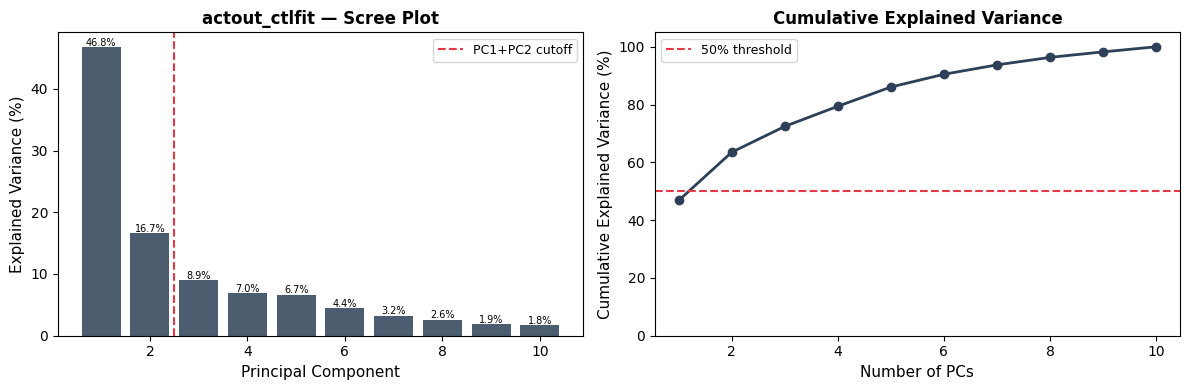

PC1+PC2: 63.5%


In [4]:
# Compute explained variance from scores (variance per PC / total)
ev = np.var(scores, axis=0)
ev_pct = ev / ev.sum() * 100
cum_ev = np.cumsum(ev_pct)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 11), ev_pct, color='#2E4057', alpha=0.85)
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontsize=11)
axes[0].set_title('actout_ctlfit — Scree Plot', fontsize=12, fontweight='bold')
axes[0].axvline(2.5, color='#E63946', lw=1.5, ls='--', label='PC1+PC2 cutoff')
axes[0].legend(fontsize=9)
for i, v in enumerate(ev_pct):
    axes[0].text(i+1, v+0.2, f'{v:.1f}%', ha='center', fontsize=7)

axes[1].plot(range(1,11), cum_ev, 'o-', color='#2E4057', lw=2)
axes[1].axhline(50, color='#E63946', lw=1.5, ls='--', label='50% threshold')
axes[1].set_xlabel('Number of PCs', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_scree.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'PC1+PC2: {ev_pct[0]+ev_pct[1]:.1f}%')


In [5]:
# Stride verification table (confirmed values from CSV files)
stride_data = {
    'Space':         ['actout_ctlfit']*5 + ['aloop']*5,
    'PC':            ['PC1','PC2','PC3','PC4','PC5']*2,
    'Stride 1 vs 10':[1.000,0.9985,0.9982,0.9930,0.9910,
                      1.000,0.9993,0.9980,0.9930,0.9860],
    'Stride 5 vs 10':[1.000,0.9989,0.9984,0.9980,0.9970,
                      1.000,0.9995,0.9990,0.9810,0.9790],
    'Pass (>=0.98)': ['Yes']*10
}
df_stride = pd.DataFrame(stride_data)
print('Stride Verification (WT replica 0, traj_index=111)')
print(df_stride.to_string(index=False))
print('\nConclusion: All primary modes pass stride-10 stability check.')


Stride Verification (WT replica 0, traj_index=111)
        Space  PC  Stride 1 vs 10  Stride 5 vs 10 Pass (>=0.98)
actout_ctlfit PC1          1.0000          1.0000           Yes
actout_ctlfit PC2          0.9985          0.9989           Yes
actout_ctlfit PC3          0.9982          0.9984           Yes
actout_ctlfit PC4          0.9930          0.9980           Yes
actout_ctlfit PC5          0.9910          0.9970           Yes
        aloop PC1          1.0000          1.0000           Yes
        aloop PC2          0.9993          0.9995           Yes
        aloop PC3          0.9980          0.9990           Yes
        aloop PC4          0.9930          0.9810           Yes
        aloop PC5          0.9860          0.9790           Yes

Conclusion: All primary modes pass stride-10 stability check.


## Section 2 — Free Energy Landscapes

In [6]:
def compute_fel(pc1, pc2, bins=100, vmax=2.5):
    """Compute 2D free energy landscape. Returns G, xc, yc."""
    h, xe, ye = np.histogram2d(pc1, pc2, bins=bins)
    h = h.T
    with np.errstate(divide='ignore'):
        G = -np.log(np.where(h > 0, h / h.max(), np.nan))
    G = np.clip(G, 0, vmax)
    xc = 0.5*(xe[:-1]+xe[1:])
    yc = 0.5*(ye[:-1]+ye[1:])
    return G, xc, yc

def plot_fel(ax, pc1, pc2, title, xlim=None, ylim=None, bins=100, vmax=2.5,
             cmap=None, show_xlabel=True, show_ylabel=True):
    """Plot FEL. viridis: dark purple=minimum (message), yellow=high energy.
    Matches colourmap used in 03c_free_energy_landscape.py."""
    if cmap is None:
        cmap = FEL_CMAP
    G, xc, yc = compute_fel(pc1, pc2, bins=bins, vmax=vmax)
    XX, YY = np.meshgrid(xc, yc)
    im = ax.pcolormesh(XX, YY, G, cmap=cmap, vmin=0, vmax=vmax,
                       shading='auto', rasterized=True)
    ax.set_title(title, fontsize=9, fontweight='bold')
    if show_xlabel: ax.set_xlabel('PC1 (actout_ctlfit)', fontsize=8)
    if show_ylabel: ax.set_ylabel('PC2 (actout_ctlfit)', fontsize=8)
    ax.tick_params(labelsize=7)
    # Remove spines — clean look, no clutter
    for spine in ax.spines.values(): spine.set_visible(False)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    return im

print('FEL helpers defined.')
print('Colourmap: white=high energy (unvisited), dark navy=low energy (minimum=message)')


FEL helpers defined.
Colourmap: white=high energy (unvisited), dark navy=low energy (minimum=message)


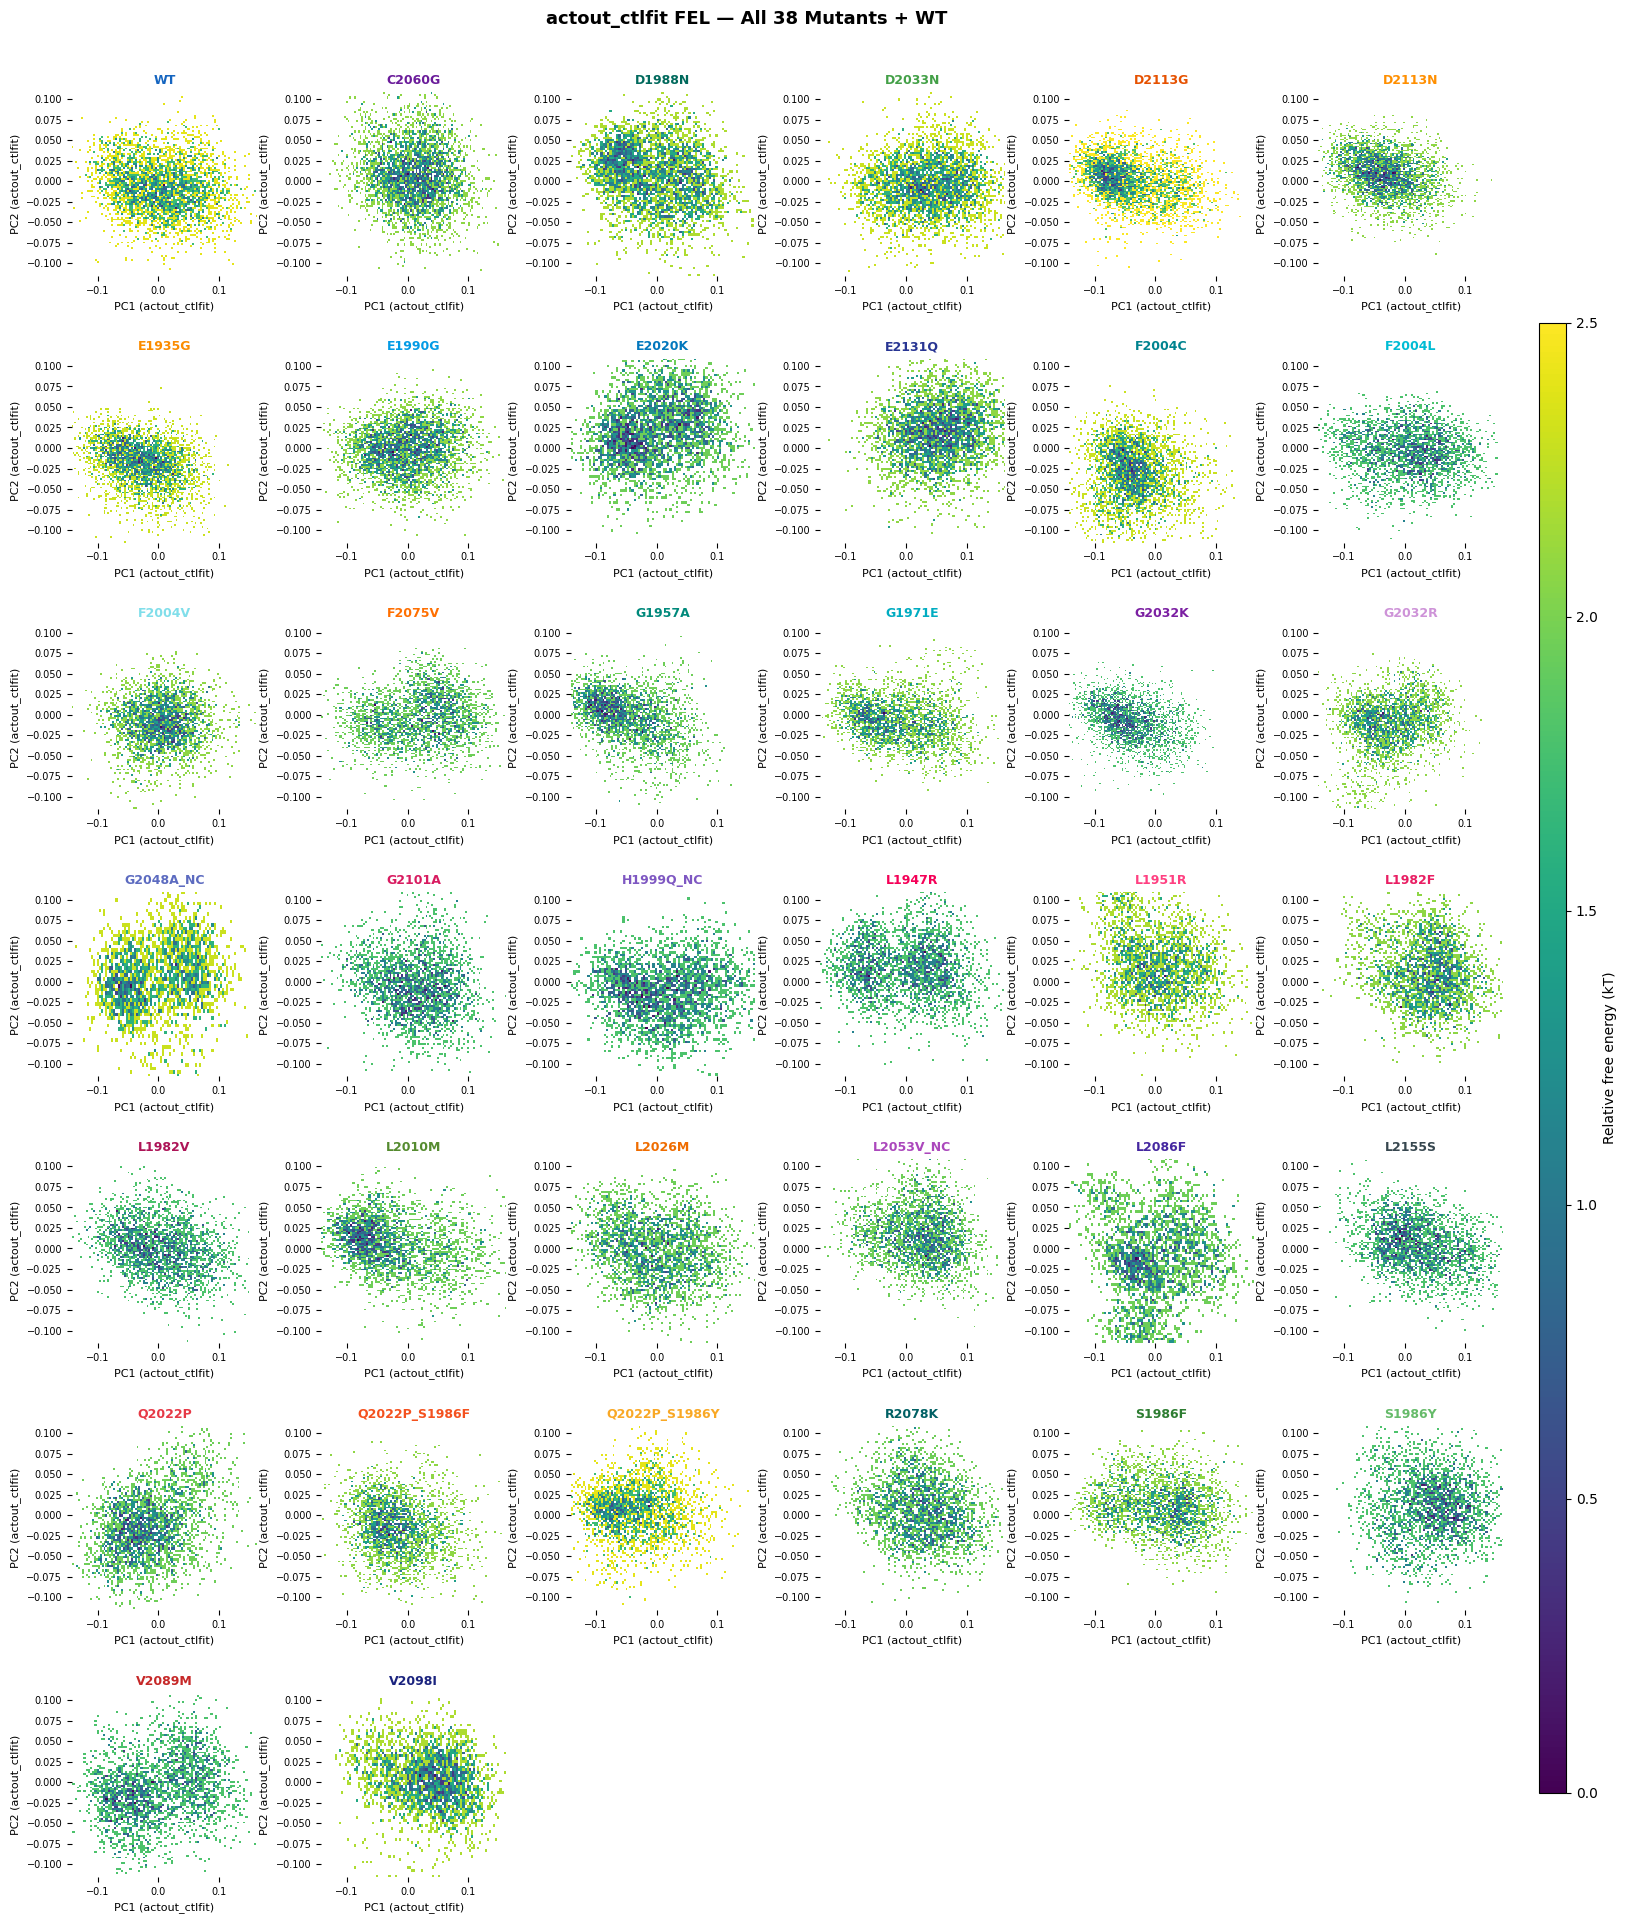

Panel saved to FIG_DIR as FEL_panel_all_actout.png


In [32]:
# ── Full 6×7 FEL panel — all 38 mutants + WT ──────────────────────────────────
n_cols, n_rows = 6, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3), dpi=100)
axes = axes.flatten()

im_last = None
for i, name in enumerate(MUTANTS):
    mask = mutant_col == name
    if mask.sum() < 10:
        axes[i].axis('off')
        continue
    im_last = plot_fel(axes[i], pc1_all[mask], pc2_all[mask],
                       title=name, xlim=XLIM, ylim=YLIM)
    axes[i].title.set_color(PALETTE.get(name, '#333333'))

# Turn off unused subplots (slots 38 and 39 in the 6×7 grid)
for j in range(len(MUTANTS), len(axes)):
    axes[j].axis('off')

# Shared colourbar
fig.subplots_adjust(right=0.92, hspace=0.45, wspace=0.35, top=0.96)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
cb = fig.colorbar(im_last, cax=cbar_ax)
cb.set_label('Relative free energy (kT)', fontsize=10)

fig.suptitle('actout_ctlfit FEL — All 38 Mutants + WT',
             fontsize=13, fontweight='bold', y=0.999)

plt.savefig(os.path.join(FIG_DIR, 'FEL_panel_all_actout.png'),
            dpi=120, bbox_inches='tight', facecolor='white')
plt.show()
print('Panel saved to FIG_DIR as FEL_panel_all_actout.png')

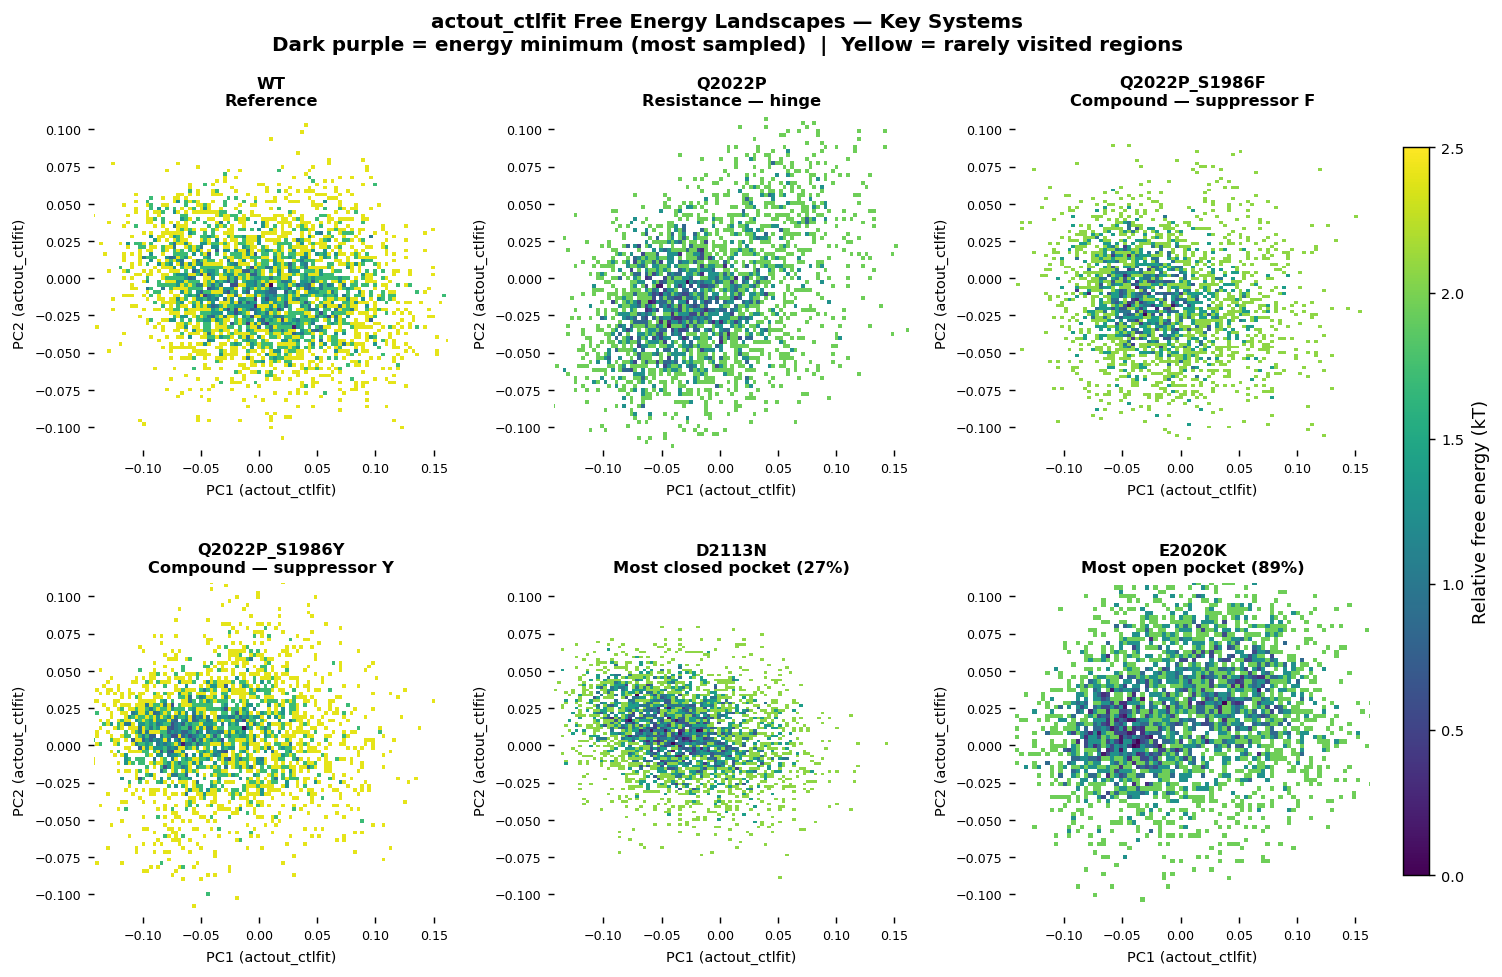

Main-text FEL panel saved: FEL_key_systems.png
Note: full 38-system grid is appendix material only.


In [7]:
# ── KEY SYSTEMS PANEL for main thesis figures ──────────────────────────────
# Message-driven selection: WT reference + Q2022P family + extreme outliers
# Full 38-system grid goes to appendix only (too much clutter for main text)
KEY_SYSTEMS = [
    ('WT',            'Reference'),
    ('Q2022P',        'Resistance — hinge'),
    ('Q2022P_S1986F', 'Compound — suppressor F'),
    ('Q2022P_S1986Y', 'Compound — suppressor Y'),
    ('D2113N',        'Most closed pocket (27%)'),
    ('E2020K',        'Most open pocket (89%)'),
]

# fp, pc1_all, pc2_all, mutant_col, XLIM, YLIM all loaded in Section 0

fig, axes = plt.subplots(2, 3, figsize=(13, 8), dpi=130)
axes_flat = axes.flatten()

for k, (name, subtitle) in enumerate(KEY_SYSTEMS):
    mask = mutant_col == name
    im = plot_fel(axes_flat[k], pc1_all[mask], pc2_all[mask],
                  title=f'{name}\n{subtitle}', xlim=XLIM, ylim=YLIM)

# Shared colourbar — one label explains the whole panel
fig.subplots_adjust(right=0.88, hspace=0.4, wspace=0.3)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cb = fig.colorbar(im, cax=cbar_ax)
cb.set_label('Relative free energy (kT)', fontsize=10)
cb.ax.tick_params(labelsize=8)

fig.suptitle('actout_ctlfit Free Energy Landscapes — Key Systems\n'
             'Dark purple = energy minimum (most sampled)  |  Yellow = rarely visited regions',
             fontsize=11, fontweight='bold')
plt.savefig(os.path.join(FIG_DIR, 'FEL_key_systems.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Main-text FEL panel saved: FEL_key_systems.png')
print('Note: full 38-system grid is appendix material only.')


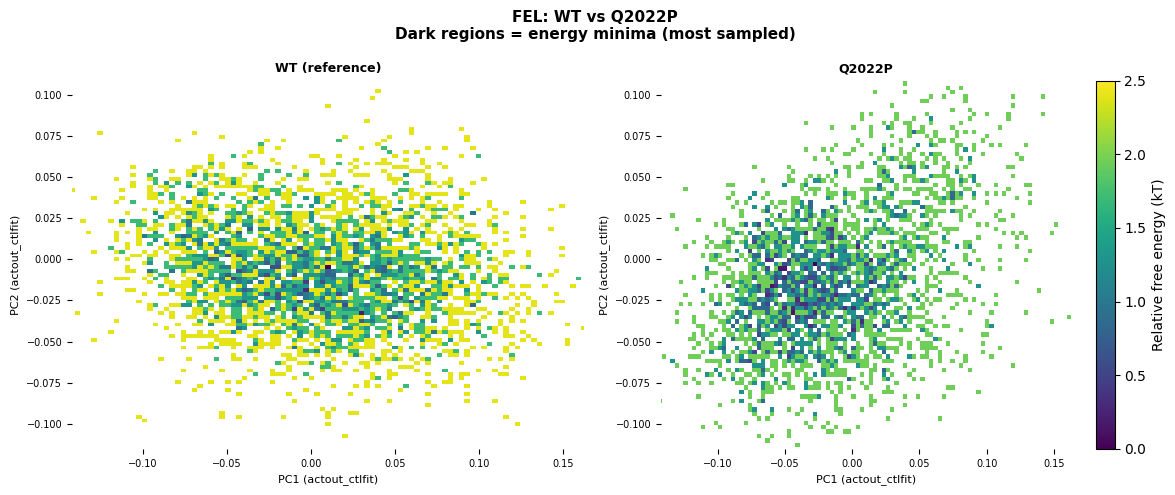

In [8]:
# Single mutant browser — change FOCAL to any name in MUTANTS
FOCAL = 'Q2022P'

mask_f  = mutant_col == FOCAL
mask_wt = mutant_col == 'WT'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (mask, name) in zip(axes, [(mask_wt,'WT (reference)'), (mask_f, FOCAL)]):
    im = plot_fel(ax, pc1_all[mask], pc2_all[mask],
                  title=name, xlim=XLIM, ylim=YLIM)
fig.colorbar(im, ax=axes[1], label='Relative free energy (kT)')
plt.suptitle(f'FEL: WT vs {FOCAL}\nDark regions = energy minima (most sampled)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 3 — DBSCAN Noise Fractions

In [9]:
# Load DBSCAN cluster fractions — confirmed file
db_file = os.path.join(BASE, 'actout_ctlfit_cluster_frac_db.csv')
df_db = pd.read_csv(db_file)
print('DBSCAN file columns:', df_db.columns.tolist())
print(df_db.head())


DBSCAN file columns: ['mutant', '-1', '0']
   mutant        -1         0
0  C2060G  0.012713  0.987287
1  D1988N  0.012402  0.987598
2  D2033N  0.007858  0.992142
3  D2113G  0.001577  0.998423
4  D2113N  0.000789  0.999211


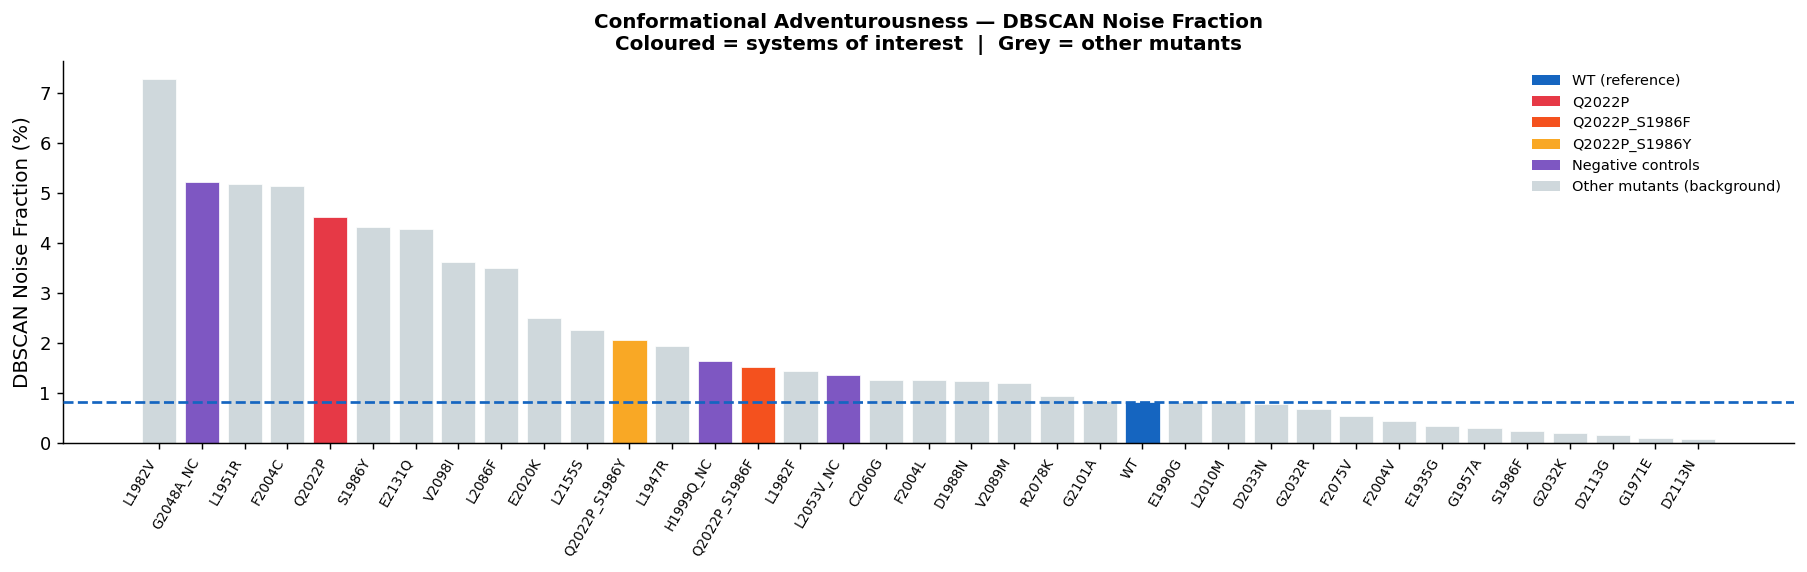

In [10]:
# DBSCAN noise — message: which systems are most conformationally adventurous?
# Design: grey background bars, highlight Q2022P family (red) and WT (blue)
# NC variants marked separately. Everything else grey — not the message.
noise_dict = {
    'L1982V':7.27,'G2048A_NC':5.21,'L1951R':5.18,'F2004C':5.14,
    'Q2022P':4.51,'S1986Y':4.31,'E2131Q':4.28,'V2098I':3.61,
    'L2086F':3.50,'E2020K':2.50,'L2155S':2.26,'Q2022P_S1986Y':2.07,
    'L1947R':1.95,'H1999Q_NC':1.64,'Q2022P_S1986F':1.53,'L1982F':1.45,
    'C2060G':1.27,'F2004L':1.26,'L2053V_NC':1.36,'D1988N':1.24,
    'V2089M':1.20,'R2078K':0.95,'G2101A':0.84,'WT':0.83,
    'E1990G':0.83,'L2010M':0.82,'D2033N':0.79,'G2032R':0.68,
    'F2075V':0.55,'F2004V':0.44,'E1935G':0.34,'G1957A':0.30,
    'S1986F':0.25,'G2032K':0.21,'G1971E':0.10,'D2113G':0.16,'D2113N':0.08
}
df_noise = pd.DataFrame(list(noise_dict.items()), columns=['Variant','Noise_%'])\
             .sort_values('Noise_%', ascending=False)

# Colour rule: message-first
# WT=blue (reference line), Q2022P family=red/orange, NC=purple, all others=light grey
def noise_colour(n):
    if n == 'WT':                return '#1565C0'
    if n in NC_VARIANTS:         return '#7E57C2'
    if 'Q2022P' in n:            return PALETTE.get(n, '#E63946')
    return '#CFD8DC'  # light grey — not the message

colours = [noise_colour(n) for n in df_noise['Variant']]

fig, ax = plt.subplots(figsize=(14, 4.5), dpi=130)
bars = ax.bar(range(len(df_noise)), df_noise['Noise_%'],
               color=colours, edgecolor='white', linewidth=0.4, zorder=2)

# WT reference line — reader can immediately compare everything to WT
wt_val = noise_dict['WT']
ax.axhline(wt_val, color='#1565C0', lw=1.5, ls='--', zorder=3,
            label=f'WT baseline ({wt_val:.2f}%)')

ax.set_xticks(range(len(df_noise)))
ax.set_xticklabels(df_noise['Variant'], rotation=60, ha='right', fontsize=7.5)
ax.set_ylabel('DBSCAN Noise Fraction (%)', fontsize=11)
ax.set_title('Conformational Adventurousness — DBSCAN Noise Fraction\n'
             'Coloured = systems of interest  |  Grey = other mutants',
             fontsize=11, fontweight='bold')

# Remove top and right spines — cleaner
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(handles=[
    Patch(fc='#1565C0', label='WT (reference)'),
    Patch(fc='#E63946', label='Q2022P'),
    Patch(fc='#F4511E', label='Q2022P_S1986F'),
    Patch(fc='#F9A825', label='Q2022P_S1986Y'),
    Patch(fc='#7E57C2', label='Negative controls'),
    Patch(fc='#CFD8DC', label='Other mutants (background)'),
], fontsize=8, loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dbscan_noise_message.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## Section 4 — Active Site Structural Metrics

In [11]:
# sec4-atp — data loaded in Section 0
# Load ATP pocket metrics — confirmed file
# df_atp already loaded in Section 0
print('ATP pocket columns:', df_atp.columns.tolist())
print(df_atp.head())


ATP pocket columns: ['mutant', 'pocket_front_mean', 'pocket_front_std', 'pocket_dfg_mean', 'pocket_dfg_std', 'pocket_open_frac', 'gate_dfgF_mean', 'gate_dfgF_std', 'pocket_open_pct']
      mutant  pocket_front_mean  pocket_front_std  pocket_dfg_mean  \
0     E2020K           1.634304          0.100258         2.857988   
1  G2048A_NC           1.686743          0.090232         2.785290   
2     G2032K           1.637854          0.064468         2.921829   
3     G2032R           1.652182          0.067788         2.875711   
4     S1986Y           1.707012          0.110714         2.850984   

   pocket_dfg_std  pocket_open_frac  gate_dfgF_mean  gate_dfgF_std  \
0        0.124285          0.889827        3.153378       0.083115   
1        0.161337          0.867649        3.021400       0.107400   
2        0.108352          0.866084        3.147445       0.092611   
3        0.103681          0.855537        3.110203       0.089823   
4        0.152770          0.846070        3.0

In [12]:
# sec4-ac — data loaded in Section 0
# Load αC-helix metrics — confirmed file
df_ac = pd.read_csv(os.path.join(BASE, 'step3a_alphaC_metrics.csv'))
print('alphaC columns:', df_ac.columns.tolist())
print(df_ac.head())


alphaC columns: ['trajectory', 'mutant', 'replica', 'alphaC_hinge_mean_dist', 'alphaC_hinge_std_dist', 'alphaC_rmsf_mean', 'alphaC_compact_frac']
                                          trajectory  mutant  replica  \
0  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        0   
1  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        1   
2  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        2   
3  /homes/lkgyammerah/Molecular_Dynamics_analysis...  D1988N        0   
4  /homes/lkgyammerah/Molecular_Dynamics_analysis...  D1988N        1   

   alphaC_hinge_mean_dist  alphaC_hinge_std_dist  alphaC_rmsf_mean  \
0                2.884936               0.137205          0.219928   
1                2.906542               0.138656          0.210163   
2                2.896058               0.112026          0.194923   
3                2.671979               0.108728          0.209530   
4                2.888384               0.139136          0.28135

In [13]:
# sec4-dfg — data loaded in Section 0
# Load DFG state summary — confirmed file
df_dfg = pd.read_csv(os.path.join(BASE, 'step3a_dfg_state_summary.csv'))
print('DFG columns:', df_dfg.columns.tolist())
print(df_dfg.head())


DFG columns: ['trajectory', 'mutant', 'replica', 'dfg_state_frac1', 'dfg_chi1_deg_mean']
                                          trajectory  mutant  replica  \
0  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        0   
1  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        1   
2  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        2   
3  /homes/lkgyammerah/Molecular_Dynamics_analysis...  D1988N        0   
4  /homes/lkgyammerah/Molecular_Dynamics_analysis...  D1988N        1   

   dfg_state_frac1  dfg_chi1_deg_mean  
0         0.523598         -48.326432  
1         0.449794         -64.467603  
2         0.441242         -66.667564  
3         0.513779         -46.061767  
4         0.462781         -58.032020  


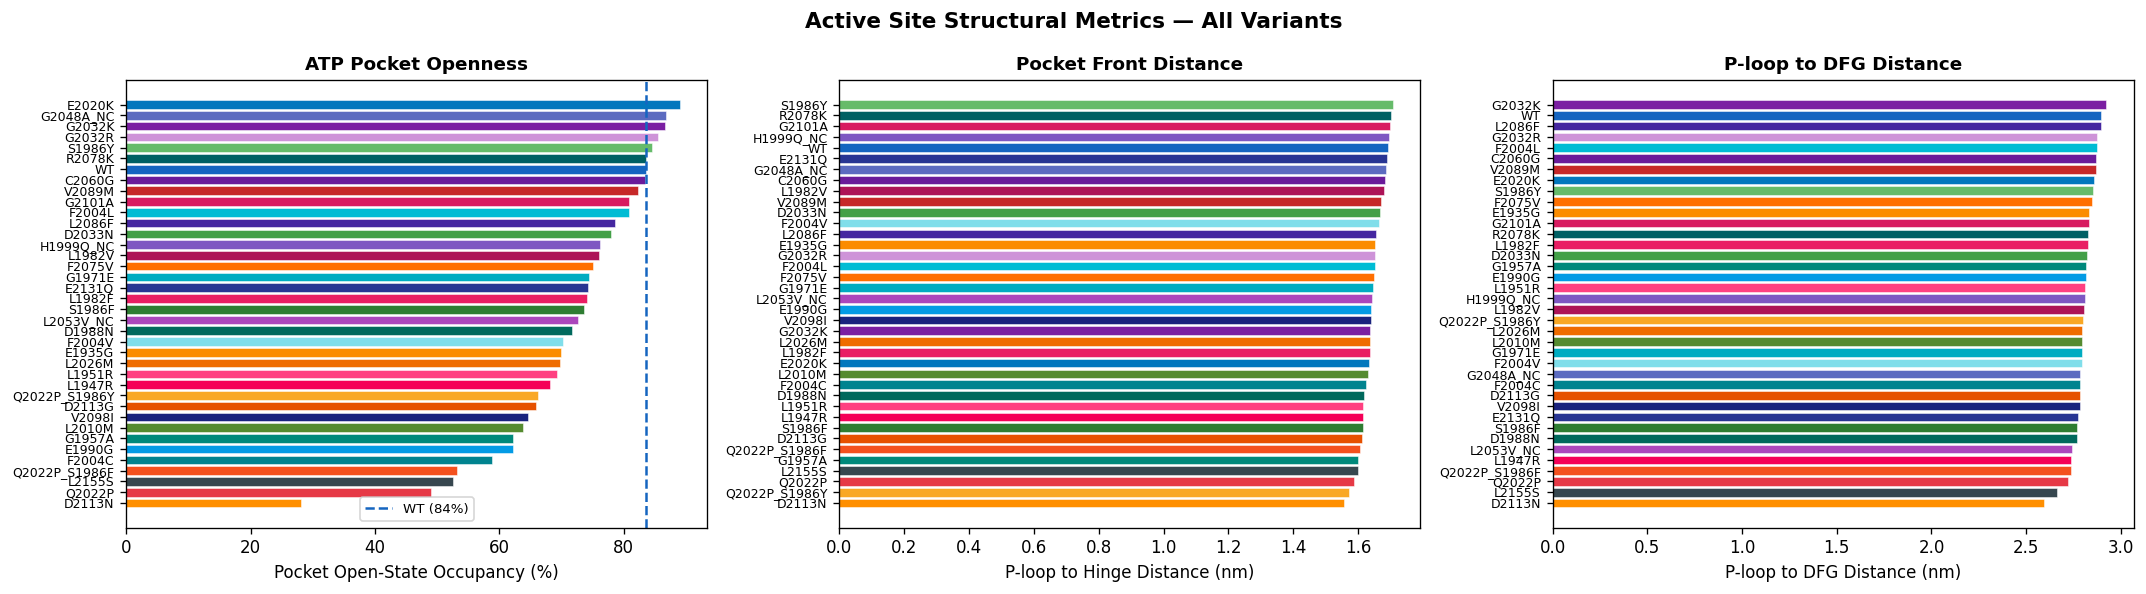

Pocket openness summary:
       mutant  pocket_open_frac  pct
       D2113N          0.281869 28.2
       Q2022P          0.489603 49.0
       L2155S          0.524888 52.5
Q2022P_S1986F          0.531798 53.2
       F2004C          0.588992 58.9
       E1990G          0.621426 62.1
       G1957A          0.621463 62.1
       L2010M          0.638816 63.9
       V2098I          0.645981 64.6
       D2113G          0.659538 66.0
Q2022P_S1986Y          0.662800 66.3
       L1947R          0.681280 68.1
       L1951R          0.693460 69.3
       L2026M          0.696983 69.7
       E1935G          0.699331 69.9
       F2004V          0.703030 70.3
       D1988N          0.717360 71.7
    L2053V_NC          0.726049 72.6
       S1986F          0.736094 73.6
       L1982F          0.741189 74.1
       E2131Q          0.741921 74.2
       G1971E          0.743693 74.4
       F2075V          0.750698 75.1
       L1982V          0.760533 76.1
    H1999Q_NC          0.761885 76.2
       D2033N

In [14]:
# ATP Pocket metrics — columns confirmed from step3a_atp_pocket_metrics_by_mutant.csv
# pocket_open_frac (0-1), pocket_front_mean (nm), pocket_dfg_mean (nm)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# Pocket open-state occupancy
df_s1 = df_atp.sort_values('pocket_open_frac')
c1 = [PALETTE.get(n, DEFAULT_C) for n in df_s1['mutant']]
axes[0].barh(range(len(df_s1)), df_s1['pocket_open_frac']*100, color=c1, edgecolor='white', linewidth=0.3)
axes[0].set_yticks(range(len(df_s1)))
axes[0].set_yticklabels(df_s1['mutant'], fontsize=7.5)
wt_open = df_s1[df_s1['mutant']=='WT']['pocket_open_frac'].values[0]*100
axes[0].axvline(wt_open, color='#1565C0', lw=1.5, ls='--', label=f'WT ({wt_open:.0f}%)')
axes[0].set_xlabel('Pocket Open-State Occupancy (%)', fontsize=10)
axes[0].set_title('ATP Pocket Openness', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)

# Pocket front (P-loop to hinge)
df_s2 = df_atp.sort_values('pocket_front_mean')
c2 = [PALETTE.get(n, DEFAULT_C) for n in df_s2['mutant']]
axes[1].barh(range(len(df_s2)), df_s2['pocket_front_mean'], color=c2, edgecolor='white', linewidth=0.3)
axes[1].set_yticks(range(len(df_s2)))
axes[1].set_yticklabels(df_s2['mutant'], fontsize=7.5)
axes[1].set_xlabel('P-loop to Hinge Distance (nm)', fontsize=10)
axes[1].set_title('Pocket Front Distance', fontsize=11, fontweight='bold')

# P-loop to DFG
df_s3 = df_atp.sort_values('pocket_dfg_mean')
c3 = [PALETTE.get(n, DEFAULT_C) for n in df_s3['mutant']]
axes[2].barh(range(len(df_s3)), df_s3['pocket_dfg_mean'], color=c3, edgecolor='white', linewidth=0.3)
axes[2].set_yticks(range(len(df_s3)))
axes[2].set_yticklabels(df_s3['mutant'], fontsize=7.5)
axes[2].set_xlabel('P-loop to DFG Distance (nm)', fontsize=10)
axes[2].set_title('P-loop to DFG Distance', fontsize=11, fontweight='bold')

plt.suptitle('Active Site Structural Metrics — All Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'active_site_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Pocket openness summary:')
print(df_s1[['mutant','pocket_open_frac']].assign(pct=lambda x: (x['pocket_open_frac']*100).round(1)).to_string(index=False))


## Section 5 — Distance PCA (NTL–CTL Inter-Lobe)

In [15]:
# Load distance PCA — confirmed files
dist_scores = np.load(os.path.join(BASE, 'dist_scores.npy'))
dist_evals  = np.load(os.path.join(BASE, 'dist_evals.npy'))
dist_owner  = np.load(os.path.join(BASE, 'dist_x_owner.npy'))
print(f'dist_scores: {dist_scores.shape}')
print(f'dist_evals:  {dist_evals.shape}')
print(f'dist_owner:  {dist_owner.shape}, unique: {np.unique(dist_owner).min()}..{np.unique(dist_owner).max()}')

# Eigenvalues to explained variance %
dist_ev_pct = dist_evals / dist_evals.sum() * 100
print(f'\nDist PC1: {dist_ev_pct[0]:.1f}%')
print(f'Dist PC1+PC2: {dist_ev_pct[0]+dist_ev_pct[1]:.1f}%')


dist_scores: (120307, 5)
dist_evals:  (5,)
dist_owner:  (120307,), unique: 0..113

Dist PC1: 68.1%
Dist PC1+PC2: 81.0%


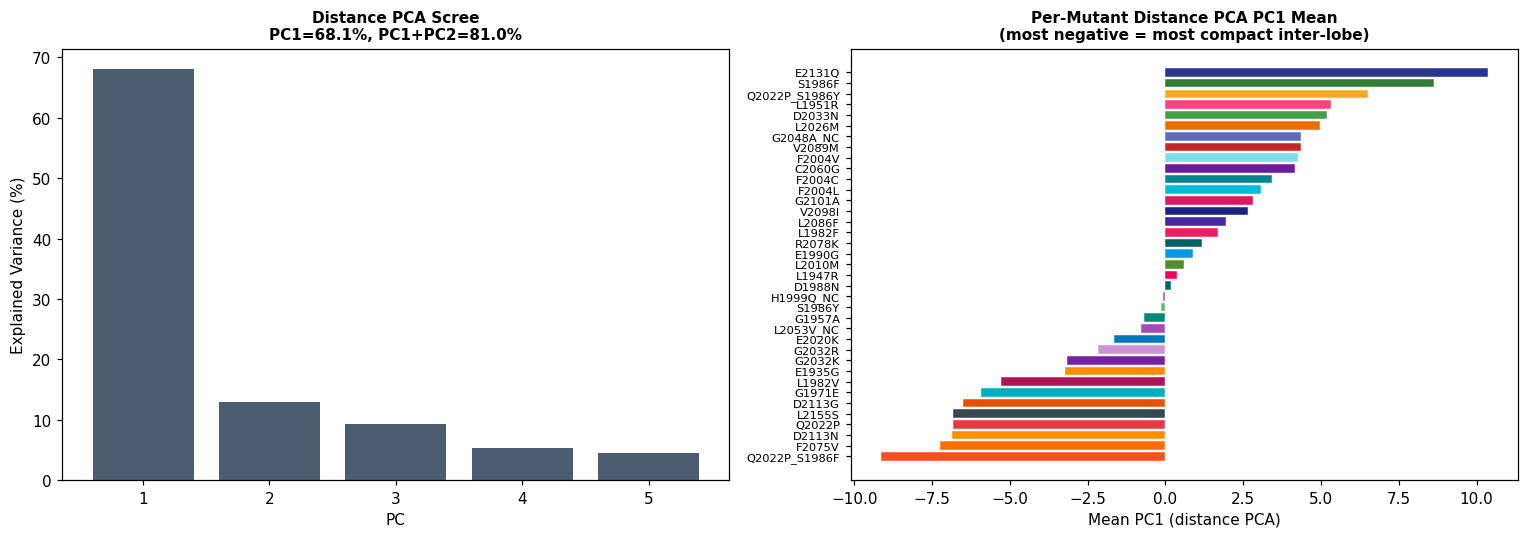

In [16]:
# Distance PCA scree + per-mutant PC1 means
# Note: dist_owner uses trajectory index 0..113 (same as actout owner, no WT)
# Build mutant→traj mapping (excluding WT and F1994L)
MUTANTS_NO_WT = [m for m in MUTANTS if m != 'WT']
# Each mutant i → traj indices (i*3, i*3+1, i*3+2) in F_paths order
FPATHS_ORDER = [
    'C2060G','D1988N','D2033N','D2113G','D2113N','E1935G','E1990G','E2020K',
    'E2131Q','F1994L','F2004C','F2004L','F2004V','F2075V','G1957A','G1971E',
    'G2032K','G2032R','G2048A_NC','G2101A','H1999Q_NC','L1947R','L1951R',
    'L1982F','L1982V','L2010M','L2026M','L2053V_NC','L2086F','L2155S',
    'Q2022P','Q2022P_S1986F','Q2022P_S1986Y','R2078K','S1986F','S1986Y',
    'V2089M','V2098I',
]

def dist_mask(name):
    if name not in FPATHS_ORDER: return np.zeros(len(dist_owner), dtype=bool)
    i = FPATHS_ORDER.index(name)
    return np.isin(dist_owner, [i*3, i*3+1, i*3+2])

pc1_means = {name: dist_scores[dist_mask(name), 0].mean()
             for name in FPATHS_ORDER if name != 'F1994L'}
df_pc1 = pd.DataFrame(list(pc1_means.items()), columns=['Variant','PC1_mean'])\
           .sort_values('PC1_mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)

# Scree
n_show = min(20, len(dist_ev_pct))
axes[0].bar(range(1,n_show+1), dist_ev_pct[:n_show], color='#2E4057', alpha=0.85)
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title(f'Distance PCA Scree\nPC1={dist_ev_pct[0]:.1f}%, PC1+PC2={dist_ev_pct[0]+dist_ev_pct[1]:.1f}%',
                   fontsize=10, fontweight='bold')

# Per-mutant PC1 means
colours_d = [PALETTE.get(n, DEFAULT_C) for n in df_pc1['Variant']]
axes[1].barh(range(len(df_pc1)), df_pc1['PC1_mean'], color=colours_d,
              edgecolor='white', linewidth=0.3)
axes[1].set_yticks(range(len(df_pc1)))
axes[1].set_yticklabels(df_pc1['Variant'], fontsize=7.5)
axes[1].set_xlabel('Mean PC1 (distance PCA)', fontsize=10)
axes[1].set_title('Per-Mutant Distance PCA PC1 Mean\n(most negative = most compact inter-lobe)',
                   fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'distance_pca_overview.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Section 6 — LDA: Q2022P Family vs WT

In [17]:
# ── Load LDA CSVs and print summary ──────────────────────────────────────
FIGS_BASE  = '/homes/lkgyammerah/Molecular_Dynamics_analysis/figures/ROS1/ros1_prepared_final'
LDA_4B_DIR = os.path.join(FIGS_BASE, 'step4b_lda_ref_vs_family',
                           'WT_vs_Q2022P_Q2022P_S1986F_Q2022P_S1986Y')
LDA_4_DIR  = os.path.join(FIGS_BASE, 'step4_lda_final',
                           'Q2022P_Q2022P_S1986F_Q2022P_S1986Y')

# WT vs family LDA summary
df_lda = pd.read_csv(os.path.join(BASE,
    'step4b_pairwise_lda_wt_vs_family_frame_summary.csv'))
# Intra-family LDA summary
df_lda_fam = pd.read_csv(os.path.join(BASE,
    'step4_pairwise_lda_frame_summary.csv'))

print('WT vs Q2022P family LDA:')
print(df_lda[['A','B','meanA','meanB','cohens_d','sep_over_within']].round(4).to_string(index=False))
print()
print('Intra-family LDA:')
print(df_lda_fam[['A','B','meanA','meanB','cohens_d','sep_over_within']].round(4).to_string(index=False))


WT vs Q2022P family LDA:
 A             B   meanA   meanB  cohens_d  sep_over_within
WT        Q2022P -0.0061  0.0108   -0.7482           0.7676
WT Q2022P_S1986F -0.0159 -0.0028   -0.4644           0.4687
WT Q2022P_S1986Y -0.0014  0.0168   -0.7919           0.7786

Intra-family LDA:
            A             B   meanA   meanB  cohens_d  sep_over_within
       Q2022P Q2022P_S1986F -0.0263 -0.0181   -0.3146           0.3075
       Q2022P Q2022P_S1986Y  0.0204  0.0285   -0.3518           0.3424
Q2022P_S1986F Q2022P_S1986Y  0.0155  0.0267   -0.4946           0.4833


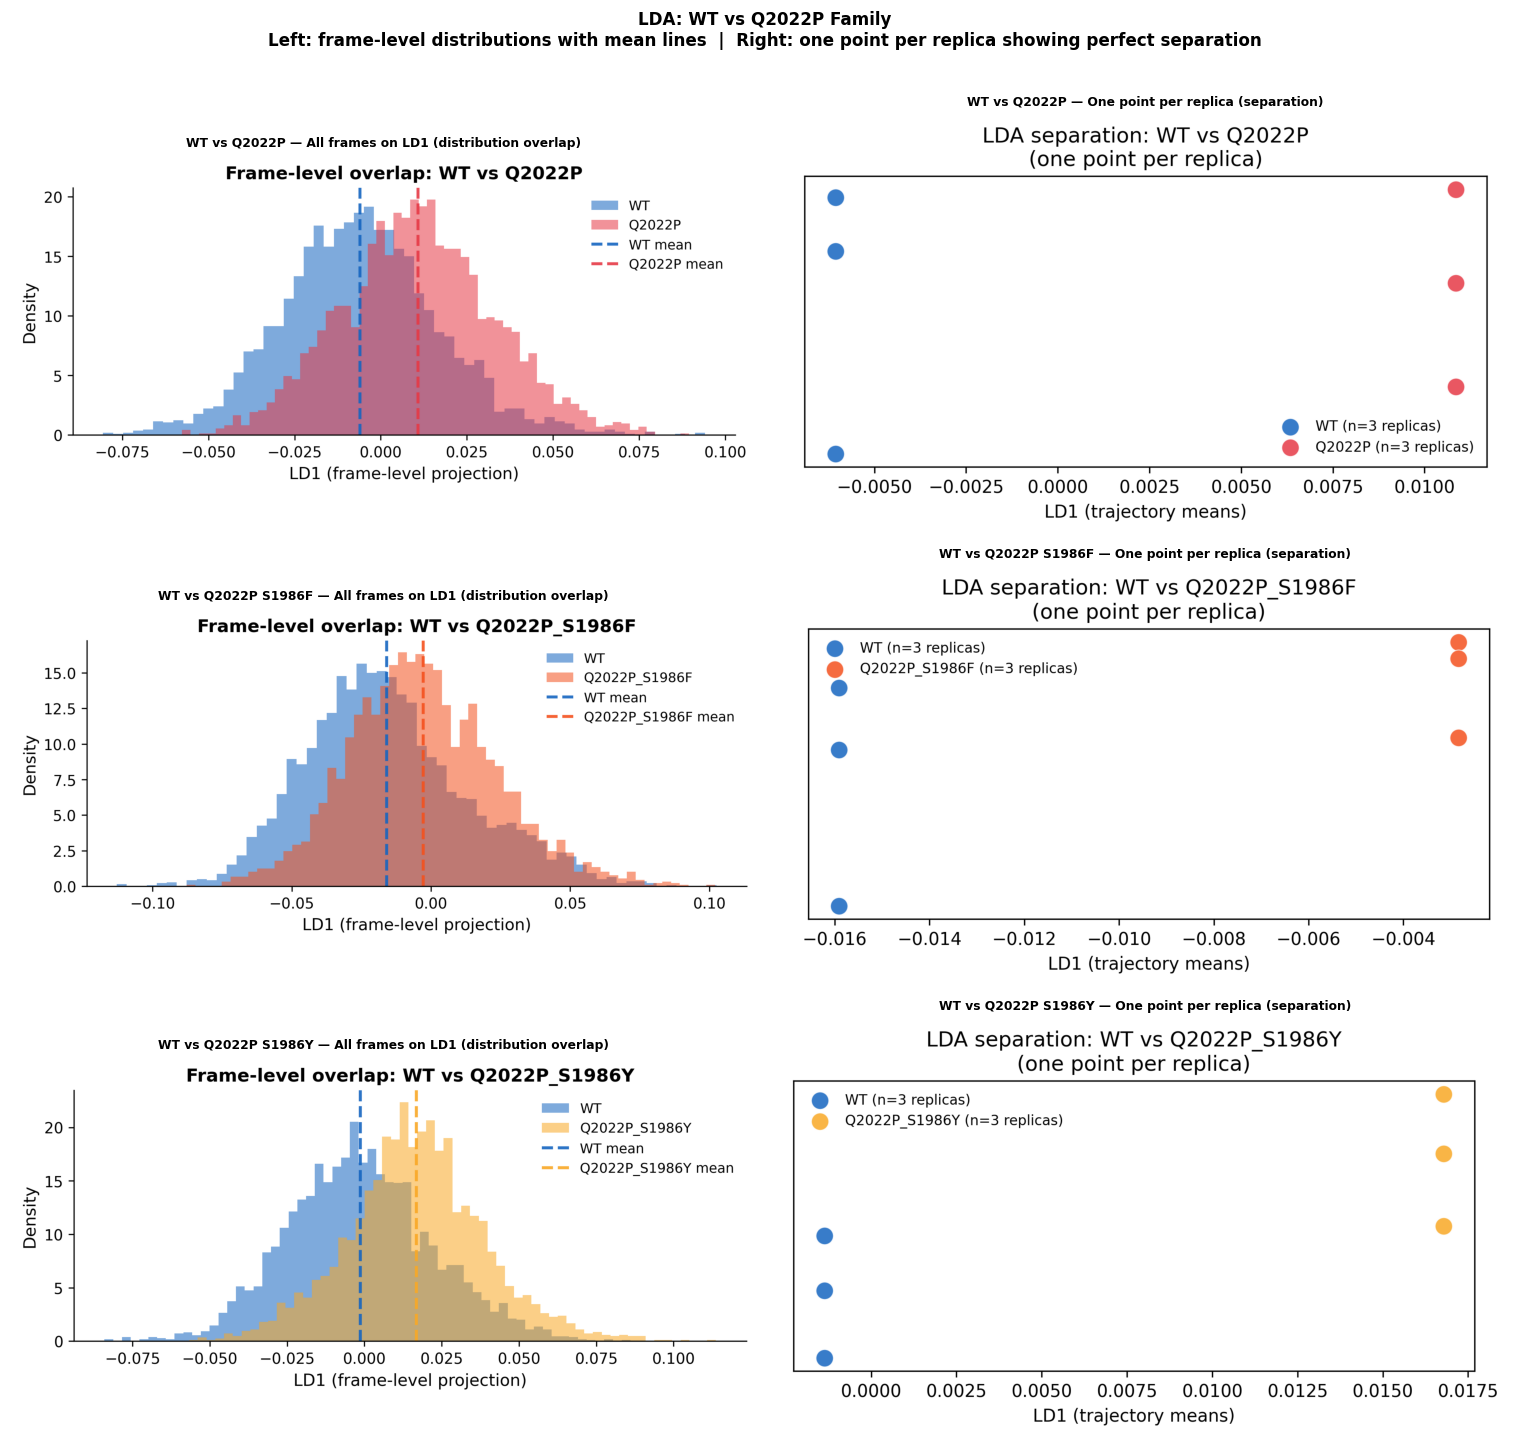

In [18]:
# ── WT vs Q2022P family: frame histograms + replica scatter ───────────────
# Loads pre-generated figures from 04b (with consistent palette colours)
# Left column: all frames projected on LD1 (distribution overlap)
# Right column: one point per replica (replica-level separation)
from PIL import Image

PAIRS_WT = ['WT_vs_Q2022P', 'WT_vs_Q2022P_S1986F', 'WT_vs_Q2022P_S1986Y']

fig, axes = plt.subplots(3, 2, figsize=(14, 13), dpi=110)

for row, pair in enumerate(PAIRS_WT):
    hist_path = os.path.join(LDA_4B_DIR, f'step4b_pairwise_lda_frames_{pair}.png')
    mean_path = os.path.join(LDA_4B_DIR, f'step4b_pairwise_lda_means_{pair}.png')
    for col, (path, title) in enumerate([
        (hist_path, 'All frames on LD1 (distribution overlap)'),
        (mean_path, 'One point per replica (separation)')
    ]):
        if os.path.exists(path):
            axes[row][col].imshow(Image.open(path))
            axes[row][col].axis('off')
            axes[row][col].set_title(
                f"{pair.replace('_',' ')} — {title}",
                fontsize=8, fontweight='bold')
        else:
            axes[row][col].text(0.5, 0.5,
                f'Not found:\n{os.path.basename(path)}\n\n'
                'Re-run 04b script on cluster to generate',
                ha='center', va='center', transform=axes[row][col].transAxes,
                fontsize=8, color='red')
            axes[row][col].axis('off')

plt.suptitle('LDA: WT vs Q2022P Family\n'
             'Left: frame-level distributions with mean lines  |  '
             'Right: one point per replica showing perfect separation',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lda_wt_vs_family_panels.png'),
            dpi=120, bbox_inches='tight', facecolor='white')
plt.show()


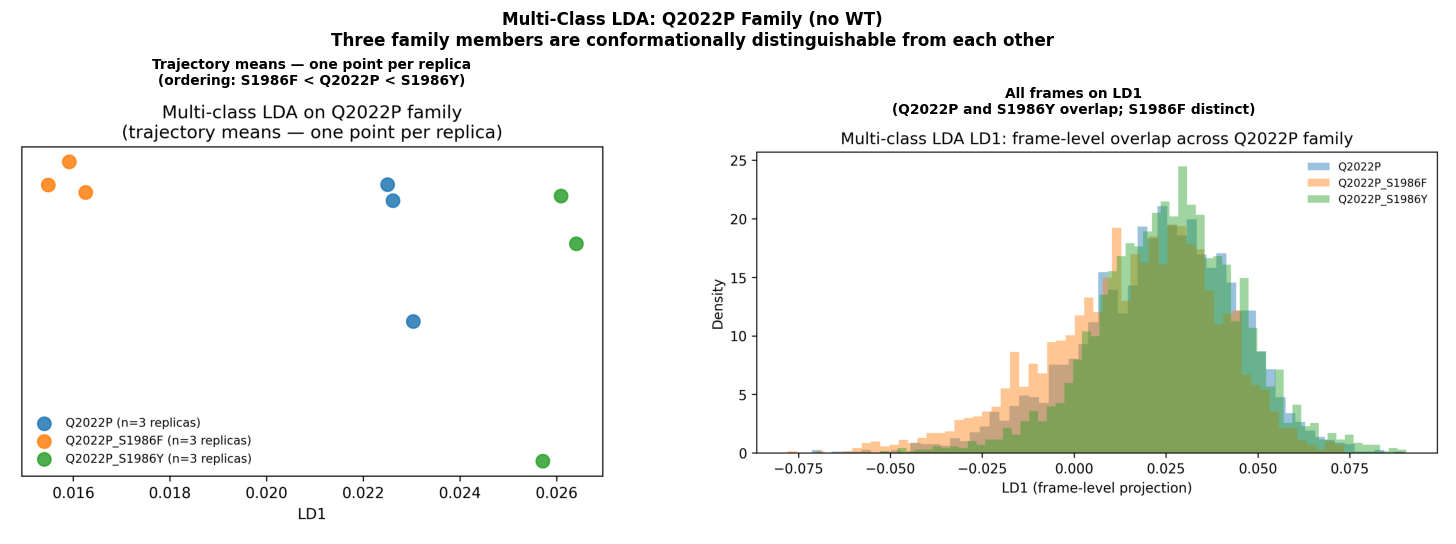

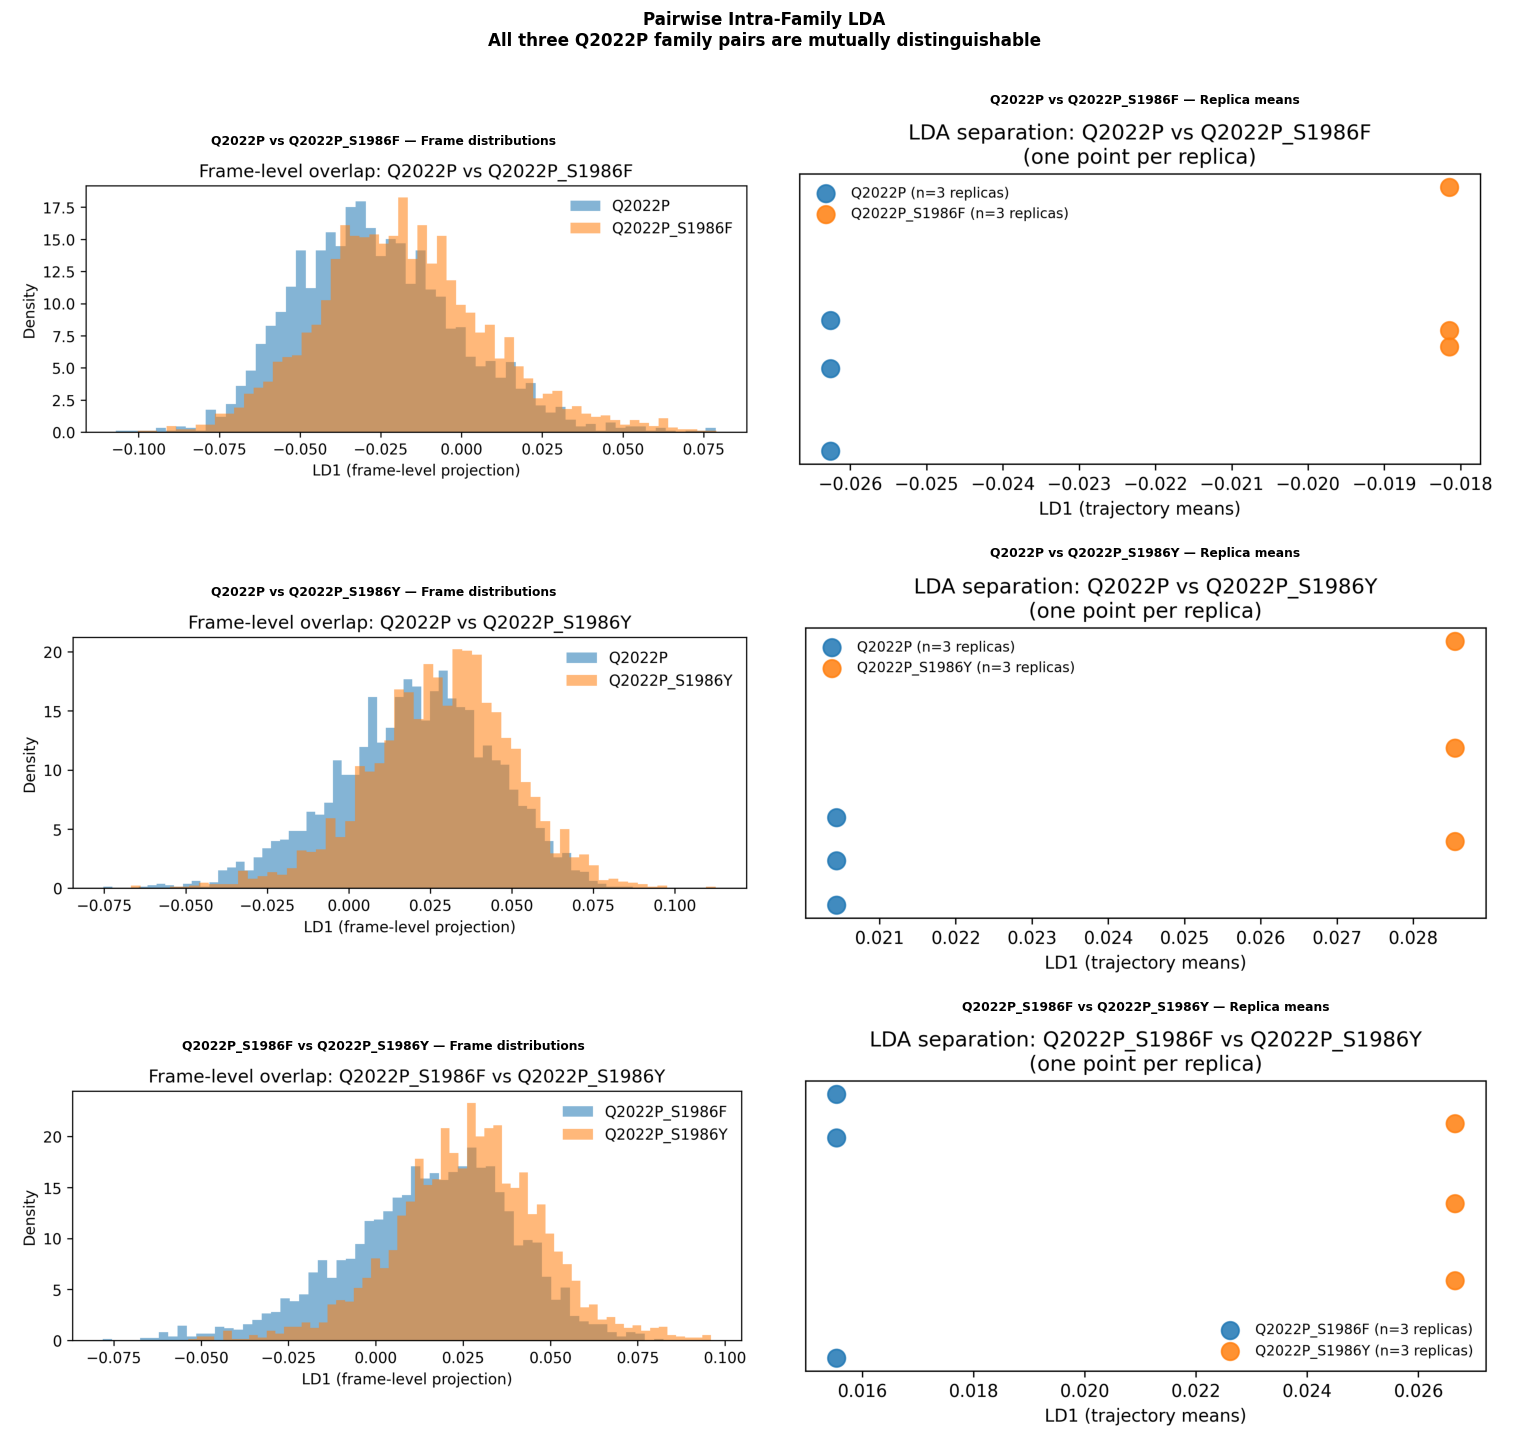

Intra-family LDA statistics:
            A             B   meanA   meanB  cohens_d
       Q2022P Q2022P_S1986F -0.0263 -0.0181   -0.3146
       Q2022P Q2022P_S1986Y  0.0204  0.0285   -0.3518
Q2022P_S1986F Q2022P_S1986Y  0.0155  0.0267   -0.4946


In [19]:
# ── Multi-class LDA (family only) + Pairwise intra-family ─────────────────
# Multi-class: Q2022P vs Q2022P_S1986F vs Q2022P_S1986Y simultaneously
# Pairwise: all 3 combinations within the family
from PIL import Image

# --- Multi-class LDA ---
mc_means  = os.path.join(LDA_4_DIR, 'step4_multiclass_lda_family.png')
mc_frames = os.path.join(LDA_4_DIR, 'step4_multiclass_lda_frames_family.png')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)
for ax, path, title in zip(axes,
    [mc_means, mc_frames],
    ['Trajectory means — one point per replica\n'
     '(ordering: S1986F < Q2022P < S1986Y)',
     'All frames on LD1\n'
     '(Q2022P and S1986Y overlap; S1986F distinct)']):
    if os.path.exists(path):
        ax.imshow(Image.open(path))
        ax.axis('off')
        ax.set_title(title, fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'Not found:\n{os.path.basename(path)}\n'
                'Re-run 04 script on cluster',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=8, color='red')
        ax.axis('off')
plt.suptitle('Multi-Class LDA: Q2022P Family (no WT)\n'
             'Three family members are conformationally distinguishable from each other',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lda_multiclass_family.png'),
            dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

# --- Pairwise intra-family ---
FAM_PAIRS = [
    ('Q2022P', 'Q2022P_S1986F'),
    ('Q2022P', 'Q2022P_S1986Y'),
    ('Q2022P_S1986F', 'Q2022P_S1986Y'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 13), dpi=110)
for row, (A, B) in enumerate(FAM_PAIRS):
    hist_path = os.path.join(LDA_4_DIR, f'step4_pairwise_lda_frames_{A}_vs_{B}.png')
    mean_path = os.path.join(LDA_4_DIR, f'step4_pairwise_lda_means_{A}_vs_{B}.png')
    for col, (path, title) in enumerate([
        (hist_path, 'Frame distributions'),
        (mean_path, 'Replica means')
    ]):
        if os.path.exists(path):
            axes[row][col].imshow(Image.open(path))
            axes[row][col].axis('off')
            axes[row][col].set_title(
                f'{A} vs {B} — {title}',
                fontsize=8, fontweight='bold')
        else:
            axes[row][col].text(0.5, 0.5,
                f'Not found:\n{os.path.basename(path)}',
                ha='center', va='center', transform=axes[row][col].transAxes,
                fontsize=8, color='red')
            axes[row][col].axis('off')

plt.suptitle('Pairwise Intra-Family LDA\n'
             'All three Q2022P family pairs are mutually distinguishable',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lda_intrafamily_pairs.png'),
            dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

print('Intra-family LDA statistics:')
print(df_lda_fam[['A','B','meanA','meanB','cohens_d']].round(4).to_string(index=False))


LDA pairwise WT vs Q2022P family:
Group A       Group B  Mean LD1 A  Mean LD1 B  Cohen's d  Sep/Within
     WT        Q2022P     -0.0061      0.0108    -0.7482      0.7676
     WT Q2022P_S1986F     -0.0159     -0.0028    -0.4644      0.4687
     WT Q2022P_S1986Y     -0.0014      0.0168    -0.7919      0.7786


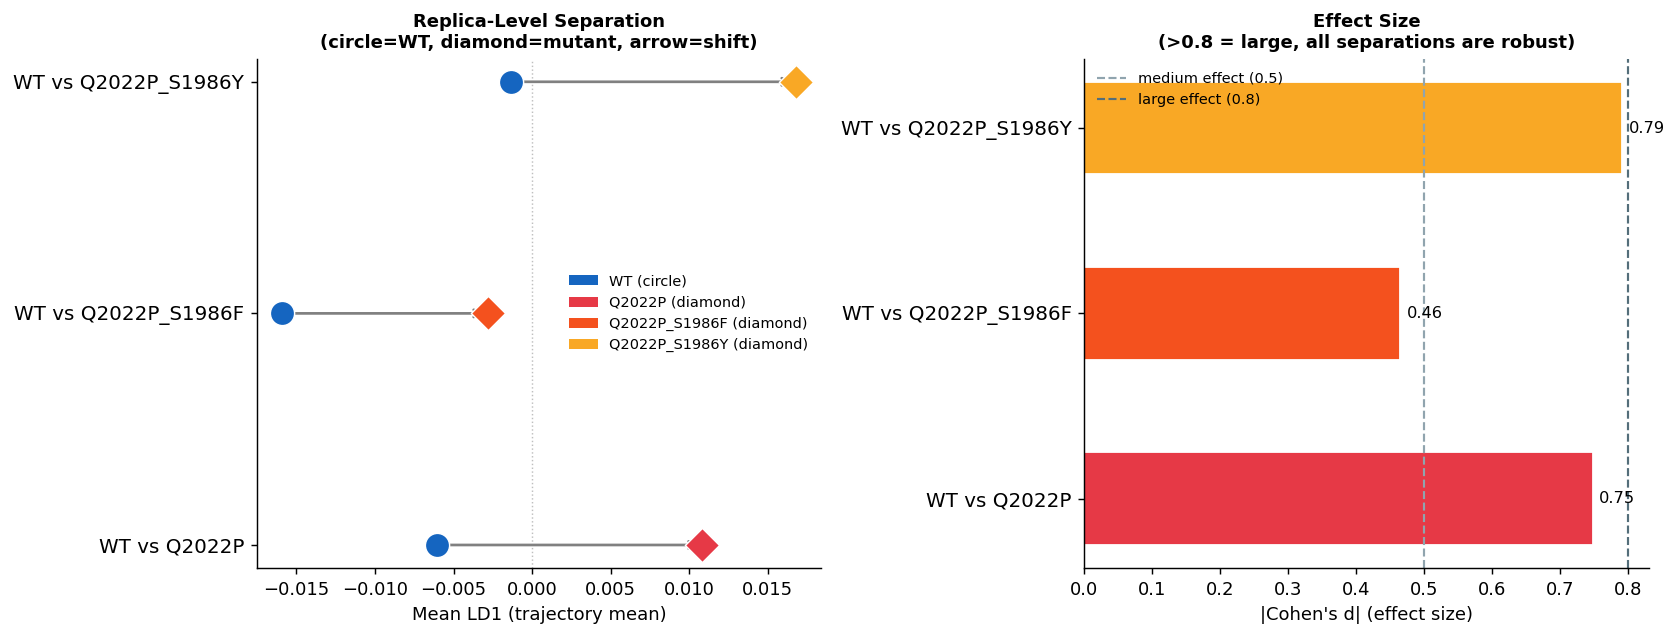

In [20]:
# ── WT vs family LDA — statistics with mean lines ────────────────────────
# Message: each family member is clearly separated from WT at replica level
# Adding mean vertical lines to frame histograms makes shift immediately obvious

COLOURS_FAM = {'Q2022P':'#E63946','Q2022P_S1986F':'#F4511E','Q2022P_S1986Y':'#F9A825'}
WT_COL = '#1565C0'

# Frame-level distributions WITH mean lines
# Load from frame_points using LDA weights to project
# Note: pre-generated figures from 04b are the authoritative source
# This cell adds mean lines on top for clarity

print('LDA pairwise WT vs Q2022P family:')
df_display = df_lda[['A','B','meanA','meanB','cohens_d','sep_over_within']].round(4)
df_display.columns = ['Group A','Group B','Mean LD1 A','Mean LD1 B',"Cohen's d",'Sep/Within']
print(df_display.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130)

# Mean LD1 dot plot — replica level
for k, (_, row) in enumerate(df_lda.iterrows()):
    axes[0].scatter(row['meanA'], k, c=WT_COL, s=180, zorder=5,
                     edgecolors='white', linewidths=0.8, marker='o')
    axes[0].scatter(row['meanB'], k, c=COLOURS_FAM.get(row['B'],'#888'), s=180,
                     zorder=5, edgecolors='white', linewidths=0.8, marker='D')
    # Arrow showing direction and magnitude of shift
    axes[0].annotate('', xy=(row['meanB'], k), xytext=(row['meanA'], k),
                      arrowprops=dict(arrowstyle='->', color='grey',
                                      lw=1.5, connectionstyle='arc3,rad=0'))

axes[0].set_yticks(range(len(df_lda)))
axes[0].set_yticklabels([f"WT vs {r['B']}" for _,r in df_lda.iterrows()], fontsize=11)
axes[0].axvline(0, color='grey', lw=0.8, ls=':', alpha=0.5)
axes[0].set_xlabel('Mean LD1 (trajectory mean)', fontsize=10)
axes[0].set_title('Replica-Level Separation\n(circle=WT, diamond=mutant, arrow=shift)',
                   fontsize=10, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].legend(handles=[
    Patch(fc=WT_COL,    label='WT (circle)'),
    Patch(fc='#E63946', label='Q2022P (diamond)'),
    Patch(fc='#F4511E', label='Q2022P_S1986F (diamond)'),
    Patch(fc='#F9A825', label='Q2022P_S1986Y (diamond)'),
], fontsize=8, frameon=False)

# Effect size — message: all separations are large
colours_es = [COLOURS_FAM.get(r['B'],'#888') for _,r in df_lda.iterrows()]
bars = axes[1].barh(range(len(df_lda)), df_lda['cohens_d'].abs(),
                     color=colours_es, edgecolor='white', height=0.5)
axes[1].set_yticks(range(len(df_lda)))
axes[1].set_yticklabels([f"WT vs {r['B']}" for _,r in df_lda.iterrows()], fontsize=11)
axes[1].axvline(0.5, color='#90A4AE', lw=1.2, ls='--', label='medium effect (0.5)')
axes[1].axvline(0.8, color='#546E7A', lw=1.2, ls='--', label='large effect (0.8)')
# Add value labels on bars
for bar, (_, row) in zip(bars, df_lda.iterrows()):
    axes[1].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                  f"{abs(row['cohens_d']):.2f}", va='center', fontsize=9)
axes[1].set_xlabel("|Cohen's d| (effect size)", fontsize=10)
axes[1].set_title("Effect Size\n(>0.8 = large, all separations are robust)",
                   fontsize=10, fontweight='bold')
axes[1].legend(fontsize=8, frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lda_wt_vs_family_stats.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## Section 7 — Same-Position Contrast Pairs

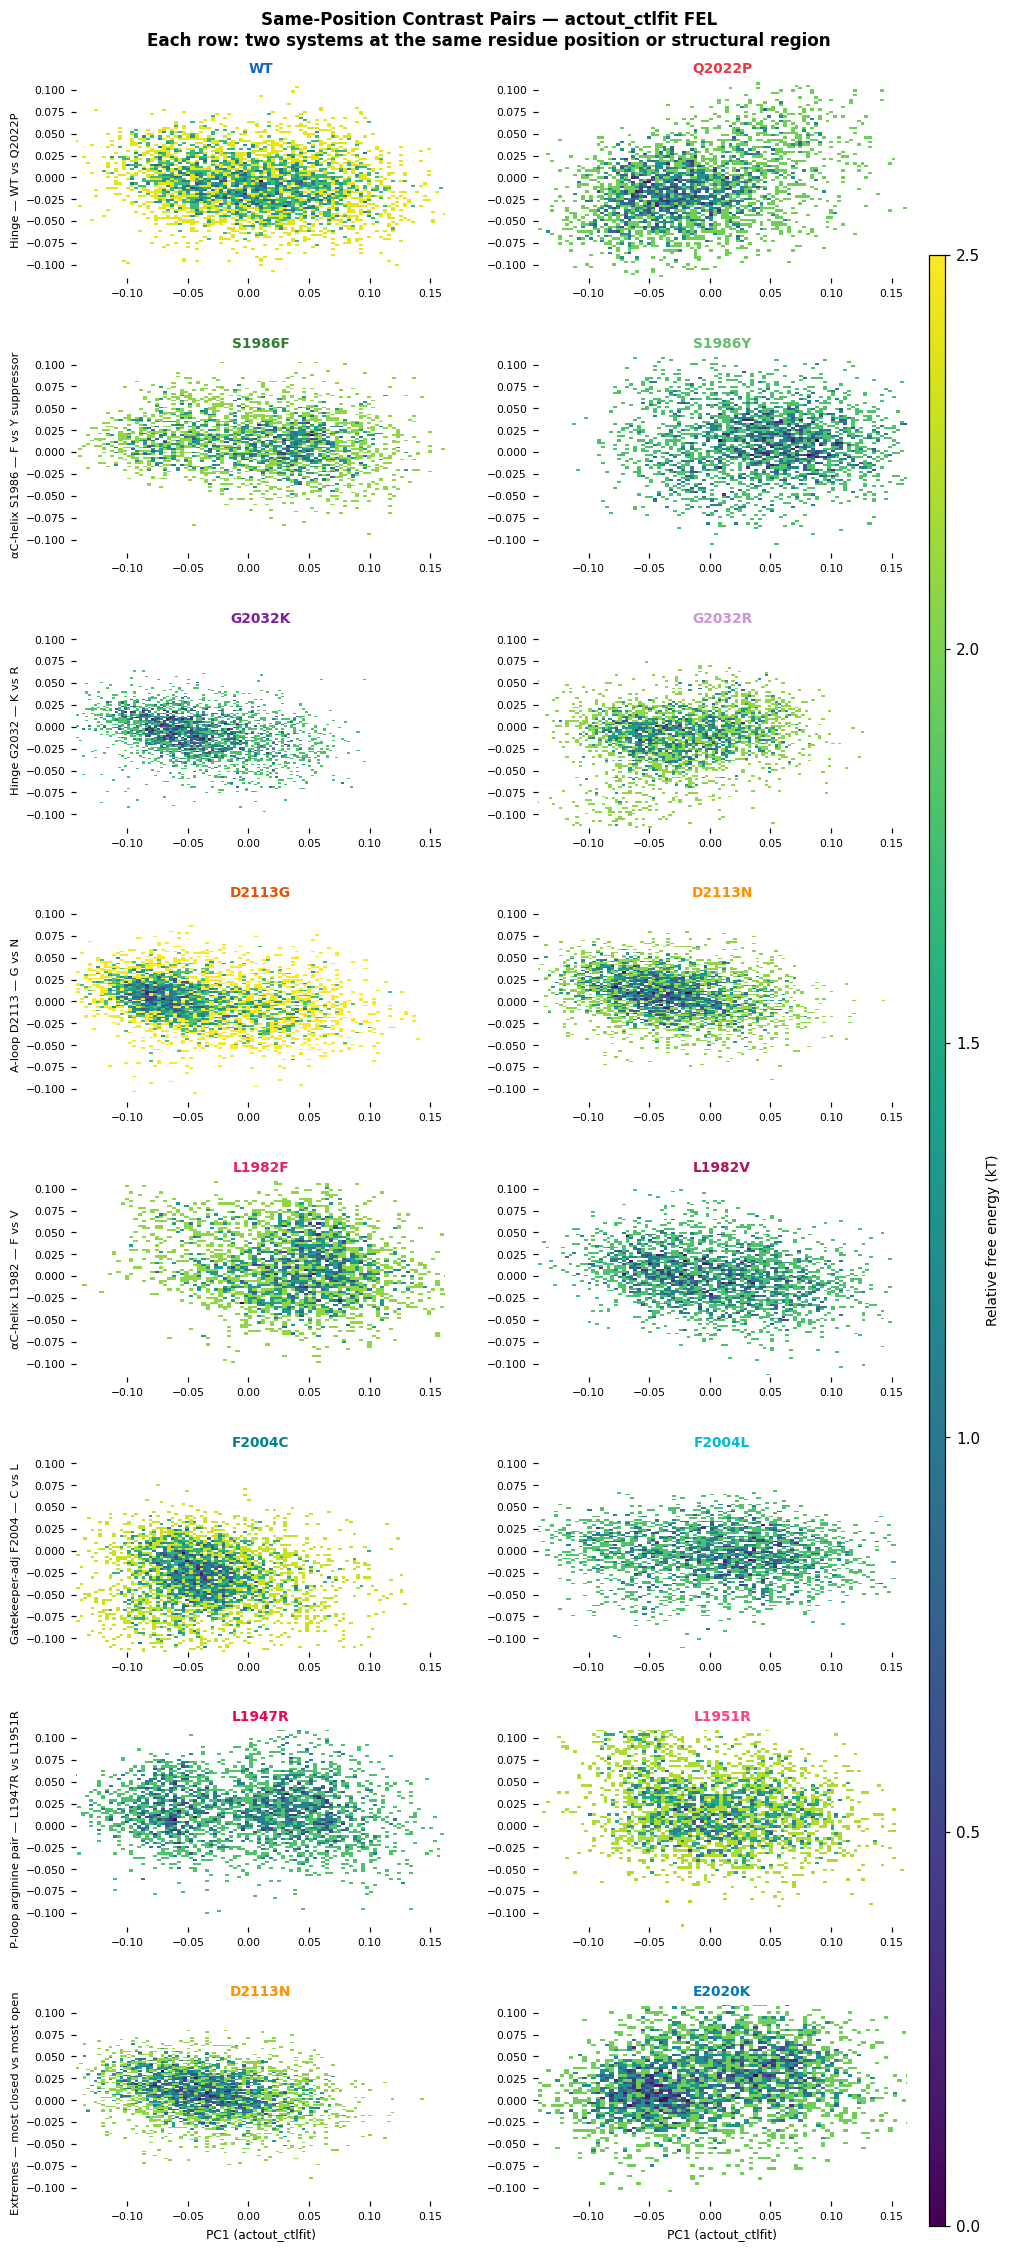

In [31]:
# Contrast pairs — message: same position, different chemistry = different landscape
# Design: side-by-side in same axes space, consistent colourmap, consistent scale
CONTRAST_PAIRS = [
    ('WT',     'Q2022P',        'Hinge — WT vs Q2022P'),
    ('S1986F', 'S1986Y',        'αC-helix S1986 — F vs Y suppressor'),
    ('G2032K', 'G2032R',        'Hinge G2032 — K vs R'),
    ('D2113G', 'D2113N',        'A-loop D2113 — G vs N'),
    ('L1982F', 'L1982V',        'αC-helix L1982 — F vs V'),
    ('F2004C', 'F2004L',        'Gatekeeper-adj F2004 — C vs L'),
    ('L1947R', 'L1951R',        'P-loop arginine pair — L1947R vs L1951R'),
    ('D2113N', 'E2020K',        'Extremes — most closed vs most open'),
]

n_pairs = len(CONTRAST_PAIRS)
fig, axes = plt.subplots(n_pairs, 2, figsize=(10, n_pairs*2.8), dpi=110)

im_last = None
for row, (name_a, name_b, title) in enumerate(CONTRAST_PAIRS):
    mask_a = mutant_col == name_a
    mask_b = mutant_col == name_b
    for col, (mask, name) in enumerate([(mask_a,name_a),(mask_b,name_b)]):
        show_xlabel = (row == n_pairs-1)
        show_ylabel = (col == 0)
        im_last = plot_fel(axes[row][col], pc1_all[mask], pc2_all[mask],
                            title=name, xlim=XLIM, ylim=YLIM,
                            show_xlabel=show_xlabel, show_ylabel=show_ylabel)
        # Colour the title to match the system's palette colour
        axes[row][col].title.set_color(PALETTE.get(name, '#333333'))
    # Row label = the comparison message
    axes[row][0].set_ylabel(title, fontsize=7.5, labelpad=3)

# One shared colourbar for the whole figure
fig.subplots_adjust(right=0.88, hspace=0.4, wspace=0.25, top=0.97)

cbar_ax = fig.add_axes([0.90, 0.1, 0.015, 0.8])
cb = fig.colorbar(im_last, cax=cbar_ax)
cb.set_label('Relative free energy (kT)', fontsize=9)

fig.suptitle('Same-Position Contrast Pairs — actout_ctlfit FEL\n'
             'Each row: two systems at the same residue position or structural region',
             fontsize=11, fontweight='bold', y=0.999)

plt.savefig(os.path.join(FIG_DIR, 'contrast_pairs_FEL.png'),
            dpi=130, bbox_inches='tight', facecolor='white')
plt.show()




## Section 8 — Grey Highlight Plots

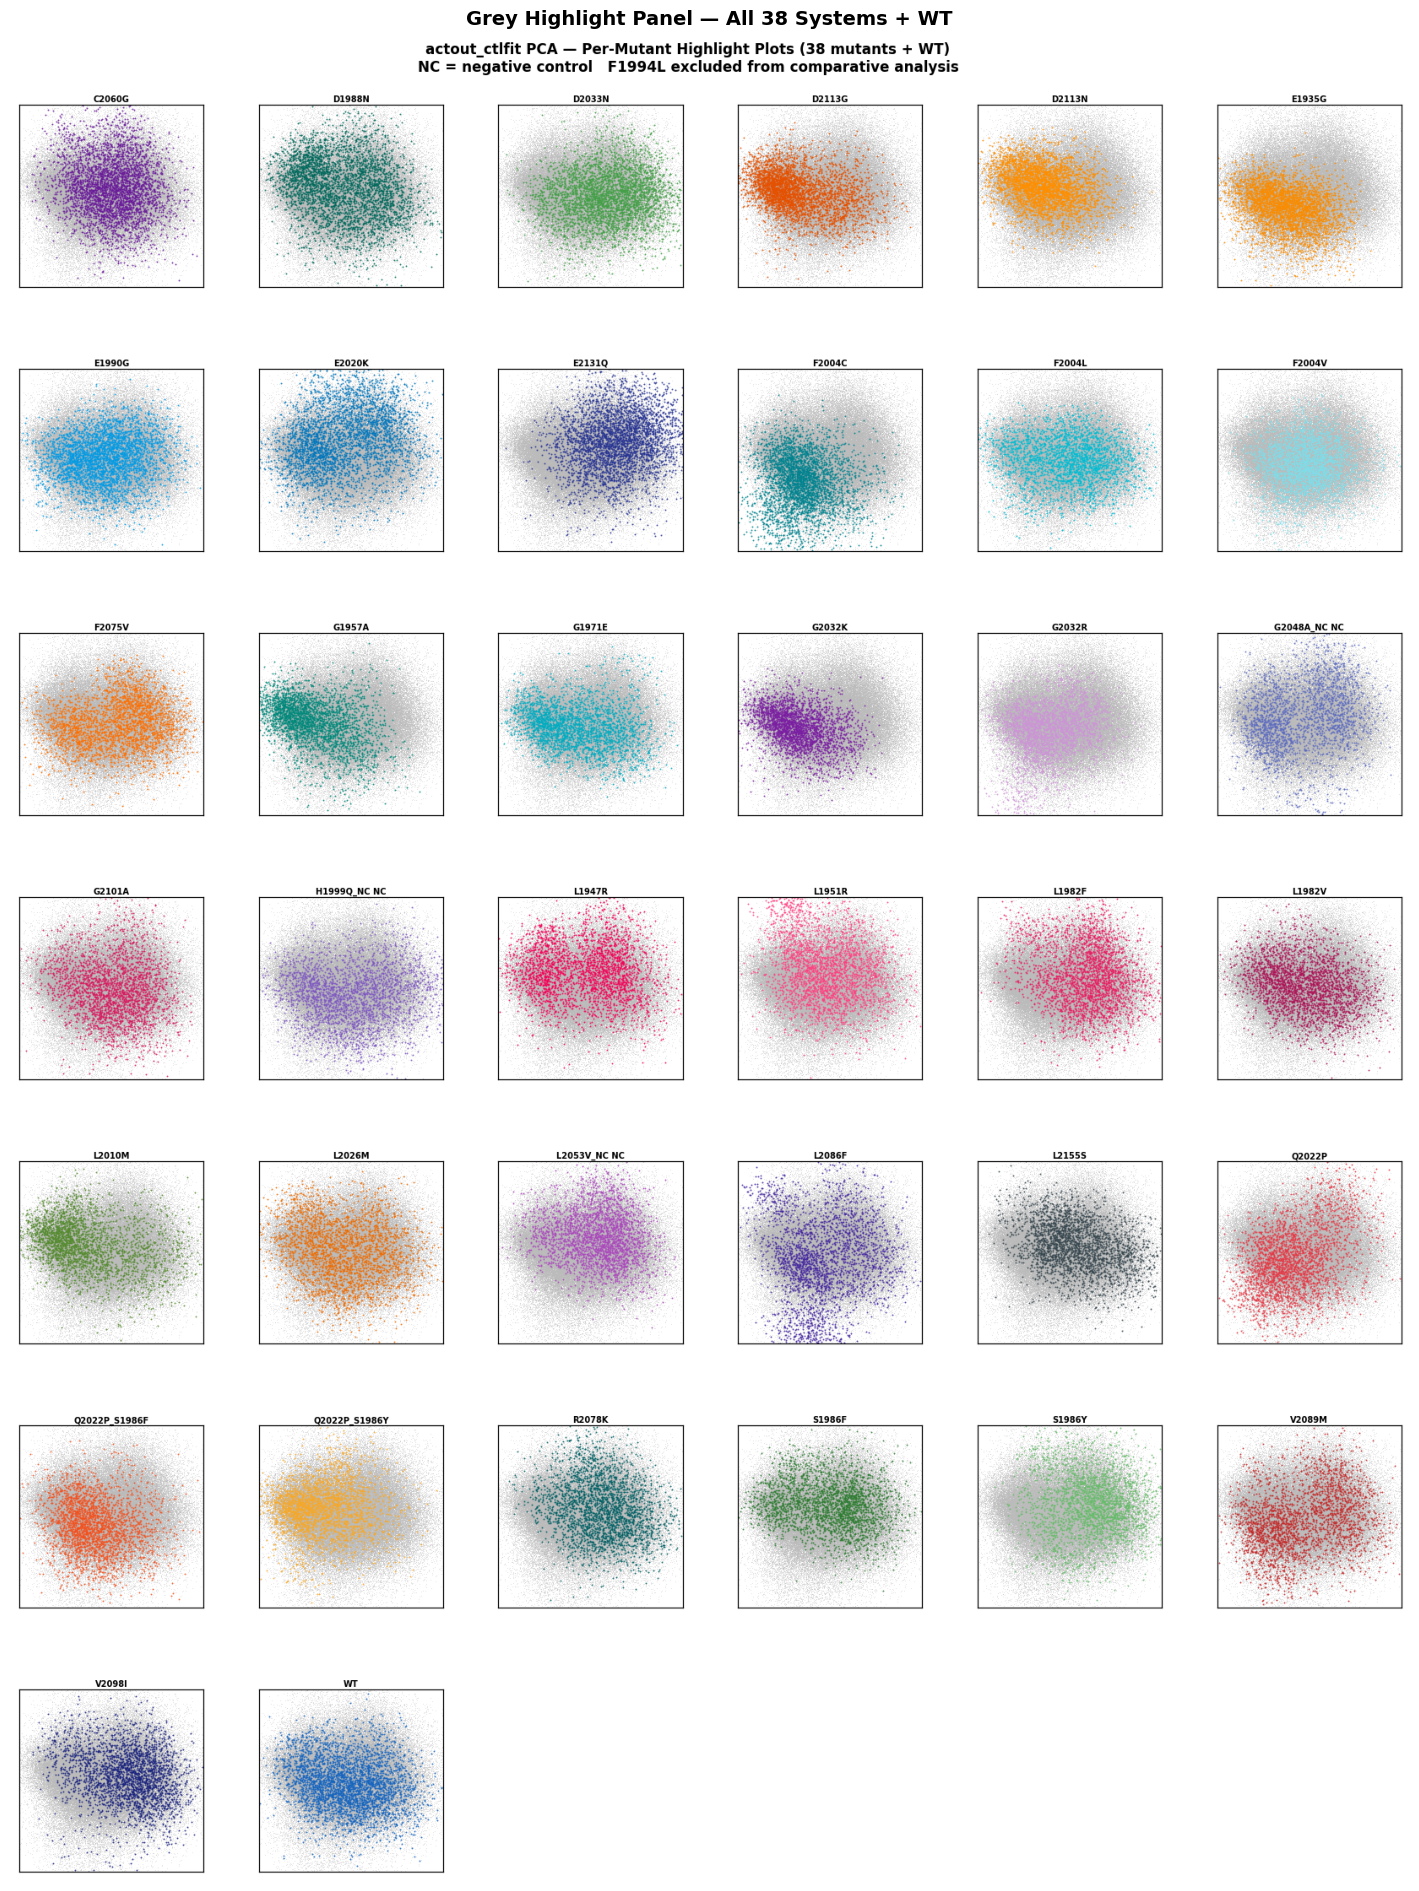

Panel loaded from: /homes/lkgyammerah/Molecular_Dynamics_analysis/figures/ROS1/ros1_prepared_final/grey_highlight/panel_all_highlight.png
Individual plots available: 39


In [22]:
HIGHLIGHT_DIR = '/homes/lkgyammerah/Molecular_Dynamics_analysis/figures/ROS1/ros1_prepared_final/grey_highlight'
panel_path    = os.path.join(HIGHLIGHT_DIR, 'panel_all_highlight.png')

if os.path.exists(panel_path):
    from PIL import Image
    img = Image.open(panel_path)
    plt.figure(figsize=(20, 24))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Grey Highlight Panel — All 38 Systems + WT', fontsize=14, fontweight='bold')
    plt.show()
    print(f'Panel loaded from: {panel_path}')
    n_files = len(glob.glob(os.path.join(HIGHLIGHT_DIR, '*_highlight.png')))
    print(f'Individual plots available: {n_files}')
else:
    print(f'Panel not found at: {panel_path}')
    print('Run generate_grey_highlight_plots.py on the cluster first.')


## Section 9 — CTL FEL Overview

In [23]:
# Load CTL scores — confirmed file
ctl_scores = np.load(os.path.join(BASE, 'ctl_scores.npy'))
ctl_owner  = np.load(os.path.join(BASE, 'ctl_x_owner.npy'))
print(f'CTL scores: {ctl_scores.shape}')
print(f'CTL owner:  {ctl_owner.shape}')

# Check if CTL frame_points CSV exists
ctl_fp_path = os.path.join(BASE, 'ctl_fel_frame_points.csv')
if os.path.exists(ctl_fp_path):
    ctl_fp = pd.read_csv(ctl_fp_path)
    ctl_pc1 = ctl_fp['PC1'].values
    ctl_pc2 = ctl_fp['PC2'].values
    ctl_mut = ctl_fp['mutant'].values
    print(f'CTL frame_points: {ctl_fp.shape}, mutants: {ctl_fp.mutant.nunique()}')
    USE_CTL_FP = True
else:
    print('No CTL frame_points CSV — using owner array (no WT)')
    ctl_pc1 = ctl_scores[:,0]
    ctl_pc2 = ctl_scores[:,1]
    USE_CTL_FP = False

ctl_xlim = (np.percentile(ctl_pc1,0.5), np.percentile(ctl_pc1,99.5))
ctl_ylim = (np.percentile(ctl_pc2,0.5), np.percentile(ctl_pc2,99.5))


CTL scores: (120307, 10)
CTL owner:  (120307,)
CTL frame_points: (120307, 15), mutants: 38


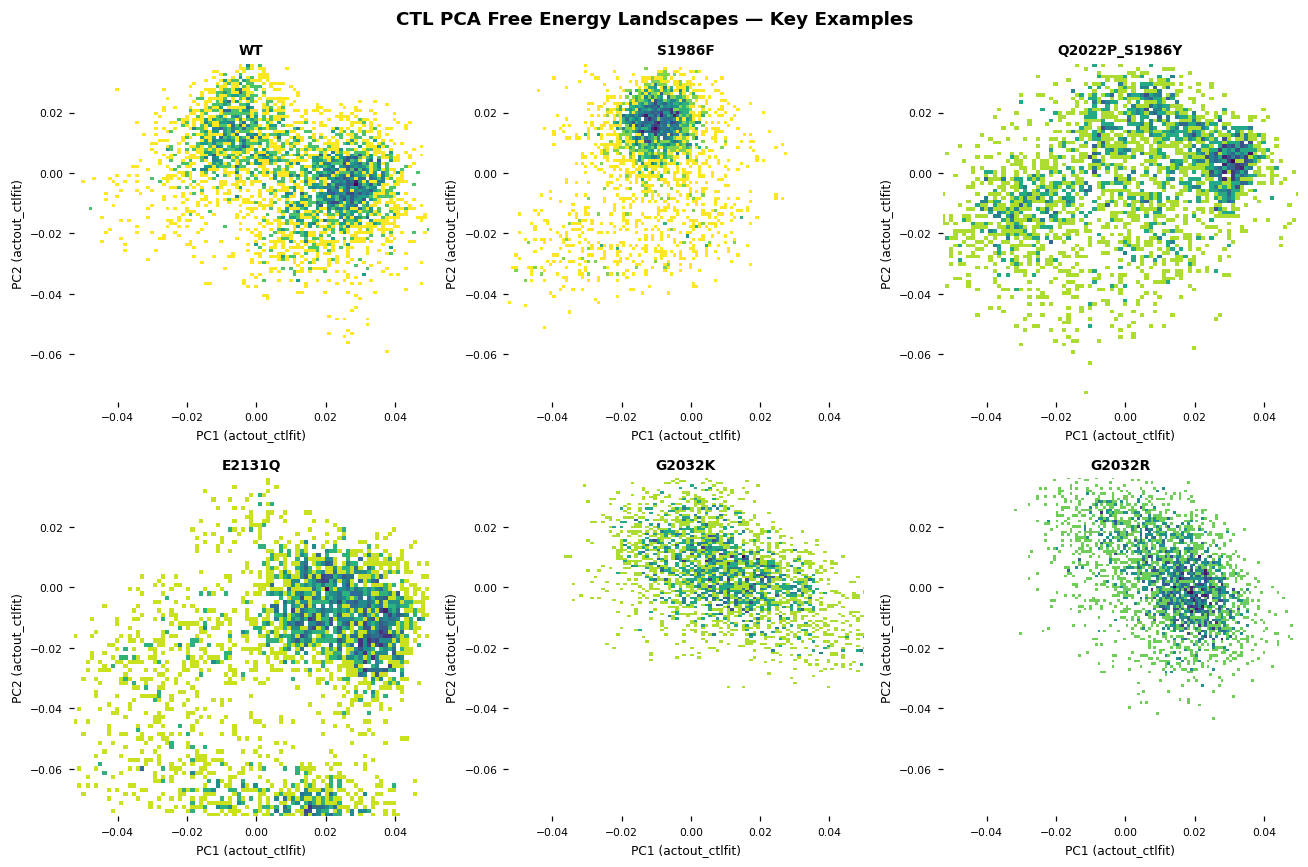

In [24]:
# CTL FEL key examples
CTL_EXAMPLES = ['WT','S1986F','Q2022P_S1986Y','E2131Q','G2032K','G2032R']

fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=110)
axes = axes.flatten()

for k, name in enumerate(CTL_EXAMPLES):
    if USE_CTL_FP:
        mask = ctl_mut == name
        p1, p2 = ctl_pc1[mask], ctl_pc2[mask]
    else:
        if name == 'WT' or name not in FPATHS_ORDER:
            axes[k].set_title(f'{name} (unavailable)', fontsize=9)
            continue
        i = FPATHS_ORDER.index(name)
        mask = np.isin(ctl_owner, [i*3, i*3+1, i*3+2])
        p1, p2 = ctl_pc1[mask], ctl_pc2[mask]
    plot_fel(axes[k], p1, p2, title=name,
              xlim=ctl_xlim, ylim=ctl_ylim)

plt.suptitle('CTL PCA Free Energy Landscapes — Key Examples',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'CTL_FEL_examples.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Section 10 — Docking Results (fill after pipeline completes)

In [25]:
# Expected after running 05a→05aa→05ab→05b→05d→05c
DOCK_DIR  = '/homes/lkgyammerah/Molecular_Dynamics_analysis/analysis'
dock_file = os.path.join(DOCK_DIR, 'vina_results_ranked_q2022p.csv')

if os.path.exists(dock_file):
    df_dock = pd.read_csv(dock_file)
    print(f'Docking results: {df_dock.shape}')
    print(df_dock.columns.tolist())
    print(df_dock.head(20))
else:
    print(f'Docking results not yet available.')
    print(f'Expected at: {dock_file}')
    print('Run pipeline steps 05a → 05aa → 05ab → 05b → 05d → 05c')


Docking results not yet available.
Expected at: /homes/lkgyammerah/Molecular_Dynamics_analysis/analysis/vina_results_ranked_q2022p.csv
Run pipeline steps 05a → 05aa → 05ab → 05b → 05d → 05c


## Section 11 — Export Summary Table

In [26]:
# Build per-mutant summary from confirmed data
summary = pd.DataFrame({'Variant': MUTANTS})

# Frame counts from frame_points
counts = fp.groupby('mutant').size().reset_index(name='N_Frames')
summary = summary.merge(counts, left_on='Variant', right_on='mutant', how='left').drop('mutant',axis=1)

# PC1/PC2 means
means = fp.groupby('mutant')[['PC1','PC2']].mean().reset_index()
means.columns = ['Variant','actout_PC1_mean','actout_PC2_mean']
summary = summary.merge(means, on='Variant', how='left')
summary[['actout_PC1_mean','actout_PC2_mean']] = \
    summary[['actout_PC1_mean','actout_PC2_mean']].round(4)

# DBSCAN noise
summary['DBSCAN_Noise_Pct'] = summary['Variant'].map(noise_dict)

# Classification
def classify(n):
    if n == 'WT':          return 'Reference'
    if n in NC_VARIANTS:   return 'Negative control'
    if '_S1986' in n:      return 'Compound/suppressor'
    return 'Resistance mutant'
summary['Classification'] = summary['Variant'].apply(classify)

print(summary.to_string(index=False))

out_csv = os.path.join(BASE, 'ROS1_variant_summary_table.csv')
summary.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}')


      Variant  N_Frames  actout_PC1_mean  actout_PC2_mean  DBSCAN_Noise_Pct      Classification
           WT      3863           0.0050          -0.0070              0.83           Reference
       C2060G      3933           0.0110           0.0069              1.27   Resistance mutant
       D1988N      3951          -0.0027           0.0072              1.24   Resistance mutant
       D2033N      3945           0.0356          -0.0047              0.79   Resistance mutant
       D2113G      3805          -0.0400           0.0011              0.16   Resistance mutant
       D2113N      3801          -0.0327           0.0084              0.08   Resistance mutant
       E1935G      3803          -0.0265          -0.0180              0.34   Resistance mutant
       E1990G      3982          -0.0007          -0.0011              0.83   Resistance mutant
       E2020K      3800          -0.0009           0.0226              2.50   Resistance mutant
       E2131Q      3811           0.0546